# Making Files

In [112]:
# separate FASTA for each sequence
import csv
import io

data = """cl_id	name	fwd_primer	rev_primer	rna_sequence
CL0105	HYER2_native_T7_IVT_gBlock	CL0106	CL0107	GUACGACGGGCAUGUCGUACAUCUGAGGUGCAAGUCCUCUGUGGACACCUGCUACCGGUGAACCCAAUAGCGACUCCCAAGCCUGACUAUCGCGAGGUAACGGGGAGAGGAAGGGAUAGCGAAAUCGUGGCUCUACGAACAGAAACGUGAUAUUAAGGCGUAUAUAGUGGAUGAGGGGGCUAGGCACUCUAAAGUCCAAAAAGGUAGUCGUAAUCUAUGUGCGUAAAUCACGAGAGUAAACGAGGAAAGAUGUACGACUUAUCCCGUGAGGUCUCAUGAGCGUCAAGUAGACGUAGUAAUAACGAAUCAUGAGAAGUCAGCCGAGGUCAUAGUAGUGAUGAAGUUUCUGUAAUGGAAACGGAGCGAAGGACCGAACGAUUAAAUGAUACCCUAUCUAACUGAUUUUGUCUGCCCUAACACCUGGUCUGAAAUGACGGUACUCGCAGAACGUAUGCUGAAAGAGGCUGCUCACAAAUAUAGGACGGCACAAGCGGAACGAAAUCAUAUAUAGGUAGGUGUGGGAACAAAAAAAGUGUUCUCGCCAAAGUUUAGUUGAACCGCCGUGUGCCGAACGGCACGCACGGUGGUGUGAGAGGGACUAUCAAUUAGUCCCUACUCGAU
CL0115	HYER round-1 design (no Notes in sheet)	CL0118	CL0119	GGUGCGCCAGGCAUGGCGCGUAGCGCCGUGACUGGCGCUGCCUGGCUCACUGUGGUGGUGAGCUGGAUGACUUGGAGGUGGAAGUCCUCUACACACCCGGCAAGGAGAAGUGUUAGCUGAAGGCAAGGGUGUCGCGGGCAACUGCGAAUCUGAAGGAAGCCGAAGGCAGACAGCCGGCCUGACGAACAGGAAGCGGAUUAGGCGGCGUAGCAGGGUGAGGUGGCCAUGAUUGCCAAAGCCCGAUACUUGCACGGAACGCUACGACGUAUAUCCGACGGGCAUAAGCAGGAAGGCACCACGUAUUACCCUAGGGUAUCUGUCAGCCUGCCAUGUGCUACCGGCAUUGUGAGGUUACGGGAUGGGCGAGCAGAUGUCAGCCGAGGCCGUAGAAGGUGCUCGGAACCGAGCAAUGAAGGGCUGAACCUGCCAUGAGCGGUAACGCAGGUGUGCUCUCUGAGCGACUCGCAGGUACAAGCUCCUUCAUACAAAGGCCUGGACAAUCAGGAGGUAGACGCCGGAGUUCCCGAGAGCCUGUAAGGCAUCUCGGACUAGGCGGGUGACAUAUCGAAUGAAACCAAGCUCGCUGAUGCAGUUUGUCAGUAGGCAGGAACCGCCGUAUACGGAACCGUACGUACGGUGGUGUGGGAGGACGGCGGGGGCGCGGCCCGCCUCUCCUACCCGAC
CL0116	HYER round-1 design (no Notes in sheet)	CL0118	CL0120	GGUGCGCCAGGCAUGGCGCGUAGCGCCGUGACUGGCGCUGUUCGGUUCACUGUGGUGGUGGACUGGACGACUUGGAGGUGAAAGUCCUCUACACACCCGGCAAGGGGAAGUGUUAGCCAGAGGCACGGGUGUCGCGGGCGACUGCGACUCUGAAGGAAGCCCGAGGCAAAAUGCUGGCCUGACGAACAGGAAGCGGAUAGAGGCAGCGUAGCGGGGUGAGGUAGCAACGAUUGCCAAAGCCCGAUUCUUGCACGGAACGCUACGACGUAAAUCCGACAGGCAUAAGCAGGAAAGUCGCGCGAAUCACACUGGGAGACCUGUUUGGCCUGCCAUGUGCUACCGGCCCCGAGAGGUGCGGGACGGGCGAACAGAAGUCAGCAGAGGCCGUAGUCUUUGCUCGAAACCGGAGCGAGUGAGGGCUGAACCUGCCGUGAGAGGAUAGCCAGCAGGGCUCUCUUUAGGAGAGUAAAGCAGAAACGCCGUGAAAAGCGGUGGUCGAGACCAUCAGGAGGUAGGGGUCGGAAACUCCGAGGGCCGGUCUGGGGGCUUAGCUACCGCAGGCAACACAUCAACGGAACCAAGCUCACUGAUGCUGUUUGUCAGUAGGCAGGAACCGCCGUAUACGGAGCCGUACGUACGGUGGUGUGGGAGGACGGCGGGAGUGUGCCCGCUUCUACCCGAU
CL0117	HYER round-1 design (no Notes in sheet)	CL0118	CL0121	GGUGCGCCAGGCAUGGCGCAAAGCGCCGUGACUGGCGCCAGCUCGGCUUACCGUGAGGGCGGAGUGGACAACUUGGAGGCUAAAGUCCUUUAUGCACCAGGCAAGGGGGAGUGUUGCCAGAUGCACCGGUGUCGCGGGGGGAGACGGGUUCUGAAGGAAGCCCGAGGCAAAAUGCCGGCCUGACGAACAGGAAGAAAUAGAGGCAGCCUAGCGGGUGAGGUAGCAACGAUUGCCAAAGCCCAAUACUUGCACGGAACGCUACGACGUAAAUCCGACAGGCAUAAGCAGGAAGGUCGCGCGAAUUACCCUGGGAAAUCUGUUCGGCCUGUCAUGUGCUACCGGCCCUGAAAGGUGGCGGGAUGGGCGAACAGGAGUCAGCAGAGGCCGCAGUAGUUGCUGGAAACCGGAGCGACCGAGGACUGAGCCGGCCGCGAGUGGAUAGUCAGAUGUGCUGGCUGUUGAAGCGUGAAGCAGGAACGCCGUGAACAGCGGUGGUCGAGACCAUCAGGAGGUGAGAGUCGGAAACUCCGAGGGCCGGGCUGGGCGCUUAGCUGCCGCAGGCGACACAUCAACGGAACCAAGCUCACUGAUGCUGUUUGUCAGUAGGCAGGAACCGCCGUAUACGGAGCCGUACGUACGGUGGUGUGGGAGGAGGGAGGGGGUUGACGCUCUUUCCGCCCAAC
CL0154	HYER_A1_root8_t1_s2_TRSgraft	CL0134	CL0142	GGUGUGCCGGGCAUGGCACUAGACUUGUCGGGUGAAAGUCCCGAUACCAGGUAUUCGCGGAGCCGAAGGUUAGCGAAAGAGCAAGGGCGUCAUCGCGAGGUGGGGUCUGAAGGAAGCUCAACGCAAAUUGGCGGGGCGACGAACAGAAACUGGAUAUGAGGUGUGGCGUACUCGGGGCGAGCUGGCUAGGCACAGCGAAGCCCUCCAUCCGCAACUGGGGUGCGCUUUAUAAACCCAGCGUCUACGCCAUGAAAGUCUGGUGUCUUACCCCGGGAGGUCUGUAGCGUGGUGAGGGAUCAACUGAGGGGUGAGCAAUUGCCCCUGAUCGCGUUGCAGAAGUCAGUAGAGGGCAUAGUAUAUAGUACUGCAGUCUAGUCGGCACGGUGUUUAACCGUGGAGUGAAUAGCGGCAGGAAGGCCUGAACGGUUAAGAGGAGGAAGCCUUGCCUUGGUACUGCAGUAUUUCACUAGGUCUGGUGAAGCGGCAGUGGGCUUGACAAGUGAUCAGAACCCGGUUGGCGCACUACCGAUUCAGCUGUUUUGAAUGGACGUUCAUGACGUUGGCUCACCGUGGUAGUGGAUCAAAACAAUUAACCGAACCGCCGUGGUACGUGACCCGUAUGCCCGGUGGUGUGGGAGGGAGGCGCCGUGAUGCAUCUCUCUGCACCUGU
CL0155	HYER_A2_root5_t3_s1_TRSgraft	CL0135	CL0143	GGUGCGCCCGGCACGUGCAUGCACCAUGGGGUGGUAAGUCCCGAACCCCGAAGACAGUAGUAGUUGAGAACCAAGAGCAAGGGUGUCCGUGGUGACGCGGAAUCUGAGGGAAGCUGCAGGCAAAACACAAGUCCGAGGAACACGAACCUCAUAUAAGGCUAGGUAUGAUUGAGUGAGUAGGCAUAACAAAGCAAAGCUCUUCCUGUCGAAGGUCAUAUCGAGUAAAUGACACAGAUAGAUAUGGUGAAUAUGUGGACGUACGUUCCCGGGGAGGUCUAGCGGAUGUGACAGGUACUCUUCAUAACUUACUUAGUGAUAAGUAGUUGAACCGUCAGAAAUCAACACAGGUCAUAGUACUAGUUGGCAUAGAACAACUAGCAGGGACCAAGCAAUUAAGGGAUUCGAGUCCUUGAAAUUCAGUUCGUCAUGAUGAGCACAGGAAGUGUAGUACCUCACUUGAGGGAGGAAAUGGUGAAUCCCAUGGGAGUCCCUUGGGGGGCAGAGUGACCACUGGCAUAGAGUGAACAACUAUUUGCAAAAGCUAUAAAAGCUUGUGUCAAUUAUCUUAAUUGAACCGCCGUAUACGGAACCGUACGUACGGUGGUGUGAGAGGACGGGAGCUAAUGGCUCCCUCCUACUCGAU
CL0156	HYER_A3_root3_t3_s1_TRSgraft	CL0135	CL0144	GGUGCGCCCGGCACGUACGUGAACACUGGGAUGCAAUGUCCGAACUCGGAAGACGGAAGUUGAGGUUGCCCAAUUAAGGGCGUCCGCGAUGAAGCGGGAUCUCUAGGAAGGGGGUGGUCAAACAUCUGUCCGAGGAACACACACCUCGUCUACGCUGUAAGUGUGAACAGGACUAGGCACUUUCUGUCGGAGGUCACGUCGAGUAAAUGGGGCGAGCAGGGGGUGCGAGAGUGCACGUACUUACCCGGGUACGUAUGAUGGAUAUGAGAAGUAUCCUUCAUAAACUACUCAGUGAUAAGCCGCUGCGCCGUCAGAAGCCAGCGGAGGUGGUAGUAUUAGCUGGUCUAGACCAGCUAAGAAGAACUGAACACAUGAGAGUUAUUGGCCCUUGGUAUUCCCUGAACCAUGAGCCGAACAAAGUCAUAGUAGCUCGCUUCAGAAGAGCGGUGGUGAAUAUCUAGGGAGAUCUCUUCUAGAUGCCAGAGAGGUUGCGAUAUGGACACAGGAGUUCCGAGUGGUCUAGUGACAGUGCAUCAAUUGUCGGAGCUCCAACCGUCGUAUCCGGAACUGCACGUACGGUGGUGUGAACGGAAGGGAGUUAAUUGCUCCCUCCUGCUCAA
CL0157	HYER_A4_root10_t3_s4_TRSgraft	CL0136	CL0145	GGUACGCCAGAGGUGCUGGGUAGAGCCGUGACUGGCGCUGUUCGAUGGGCCUAGUGGUCCGCUUGACGGCUUGGAGGUGAAAGUCCUCUACACACCCGGCAAGGGGAAGUGUUAGCCAGAGGCAAGGGUGUCGCAGGCGACUGUGAAUCUGAAGGAAGCCGGAGGCAAGACGCUAGCCUGACAGGAAACGGAUAGAGUUGGCUAAUUGGUGUGCUGUGGUUAGGCAGUAACCAUGACCAAAGAUAUAUACUUACACAGGGCGCUGCAACGUAAAUUCACCAGGUCAGUAUCAUUGCCCGUCGCACGACUUGCCCUUGGAGCGUUUUUGAGCCGGCCAUUUGCUACCGGUCUCGGGAGGUGAUUGCUCGGGCGAGCAGAAGUCAGUAGUGGUCGUAAUAGUCUACGGAAACCGAAGCGACGAAGGGUUGUGGCCUCAGAGUGGAUUCGAUAUAAUGCUCUCUGCCGGAGCGAAAAGCAGAAACACCGCGAACAGGGGCGGCAUAGACCAACAGGAGGUAGGAGUCGGAAACUCCGAGGGCCGGUCUGGGCGCUUAGCUACCGCGGGCGACGCUUCAGCGGGUGAGCAUUCAGUGAUCGUGUCCUUUGGUAUCCAGGAACCGCUGUAUACAGAGCUGUAUGUACGGUGGUGUGGAUGGACGGCGAGGGUGGCCCCGCCGCCUACCCGAU
CL0158	HYER_A5_root11_t4_s1_TRSgraft	CL0137	CL0146	GGCAAGCCCGACACGGGCAAGAACUAUAGGGUGAAAGGCCCGUGUGGCUGUUAGAGCGACGUAUGUGGAGCUCAAUAUCCUUCAGCUGAUAAUCCCUAGCCGAAACAAUGUCUGGGUUCGUGAGCGAUCUUUGUAGAGCCACGCACUAAGGUGUGCUUUGAUGAACAGAAAUGCAUAUAUAUACCAGUUAACUAAUAAAAUAUGCUUCAAAAAUAGGCACUCUUUUAAGAGACCUUUGAAUGAUUUGGUGGAUGGCGCUGAAGGCUUUUUUGGUUAGUAGGCUAUCUCUUAACUAGAAUGACGUUAUUUUCCAUUUUUUUCUUGUUUCUUGGCAACGAGCUCAAUCGUUGACCUCAAUGUGAAUAGAAGUACUGGCCAAAAUUGAAGAGAUAGUUUCAAACCUGCUUCCAAAGUCAUAAUCGACUUUCAAUUCCAUGGCCUGUGAUGAAACUUGAUUAGGAUUGCUGAAAAUAUUAUUCAGAAGACAAGUCAGGGGUUAUGGAAAAGGCAUAGACUAUCAGCGUUCAUUGCAGAUAAAAGGUUGUGUCCUUGCGUAUCACGUAGCGGACCGGCAAGAUGUGUUCUUAUGGUUAAAUUAAGAAGGAUAGAAUUCACGGAGCACAAUCAGUUAAGACUUCCAAAACAUCUUCGGGAAACGCUCUGAAGAGCCCGCAUGCAGGGGUCUGGGAGGGCUGGAGGCUAGAGACCUCCGACUACUCGGU
CL0159	HYER_A6_root7_t4_s0_TRSgraft	CL0138	CL0147	GGCACACCCAGCAUGGGUGGUCUUUGUUUACUGAAAGAAGUACGUAUUUUAAAACGCAUAGCGCUAUAGAGUUUAGUGUAAAGCUUAACACUGUAAGCUUAGGCUGUAAGUAUCGUGAGCAACAAGAUAGUGAUGGAGUAGAAGCACUGUGGUAUAGGGCCCCAGACAGAUGUACUCGAUUAAAAGUCGCGUAGAGGAACCACGUCAUUAGGCACUCCAAAGAUUCCGAAAAAGCUGUUUAGUGGAACACGGGCGAGAAGGAGUGGCACUCGCCUGGCAACAGGCAGGUGAGAUUUCAUUACCUUGGGAAACGCAGCAUAAGCAGUGGCCUGCUAUAGUAGAGAAGCCAGCCGAAAUCAUGGUACUAGUUAGAAAUGAGUAGUACGAUGGCUUCGAAUGAACAGUUGGGAUGGGGCUCUUCAGAGCCGUUUCGCGAACAAAAGAAAGGGGGUGAAGACGGAGAAUUGGAAACCUUUGAAAAGAUGUAGCUUUCUCUAGAAAUAUCGACUGAUUUUUCGUAAAGUAAAGACAGUUUGCAAAGAGGGAUCGCGAAUCGCCCCGUAAGACCCGUACACCUUCCGUGUGGGAACGAAGGAAGCACUCCGUCAUUUAAUGGCGGAGAUGUCCGGUCGAU
CL0160	HYER_B1_root2_t1_s5	CL0135	CL0148	GGUGCGCCCGGCAUGUACAUGAACUAUAGGGUGUAAGUCCCGAACCCCGAAGACAGAAGUAGAGGUUAGCCAAGAGCAAGGGUGUCCGUGGUGACGCGGAAUCUGAGGGAAGCUGGAGGCAAAACACCGGUCCGAGGAACACGAACCUCAUAUGAAUAUCUUCGGUAGUGUAGUUUAAAGGCUAGGUAUGAUUGAGUGAGUUUGCAUAACAAAACAAAGCUCUUUCUGUCGAAGGUCAUAUCGAGUAAAUGAGGCGGAUAGAUGGUGUGAAAGUACAUGUACUUACCCGGGGAGGUCUGGCGGAUAUGUGAAGUACUCUUCAUAACCUACUUAGUGAUAAGUAGCUGAACCGUCAGAAGUCAGCAGAGGUCAUAGCAUUAGUUGGUCUAGAACAACUAAGAAGGACCGAAUGAUUAAGAGAAGAACCCUGGGUAUUCAGUGAGUCAUGAUGAACACAGAAAACGUAGUACCUCACUUGAGGGAGGAAGCGGUGAAUCCCGUGGGAGACCUCUUGGAGGGUGGAGUGACCACUGGCAUAAAGAGAACAGCUAUUCACGGAAGUUAUAAAGACUUGCGUUAAUUACCUUAAUUGAACCACCGUAUACGGAUCGUACGUACGGUGGUGUGAGAGGACGGGAGUUAAUCGCUCCCUCCUACUCGAU
CL0161	HYER_B2_root8_t1_s5	CL0134	CL0149	GGUGUGCCGGGCAUGGCACUAGACUUGUCGGGUGAAAGUCCCGAUACCAGGUAUUCGCGGAGCCGAAGGUUAGCGAAAGAGCAAGGGCGUCAUCGCGAGGUGGGGUCUGAAGGAAGCUCAACGCAAAUUGGCGGGGCGACGAACAGAAACUGGAUAUGAGGUGUGGCGUACUCGGGGCGAGUUGGCACGUGACAGCGAAGCCAUCCAUCCGCAACUGGAAUGCGCUUUAUAAAUCCAGCGGCUACGCCAUGAAAGUCUGGUGUACUUGCCCGGGAGGUCUGUAGCGUGUUGAGGGAUCAACUGAGGGGUGAGCAAUUGCCCCUGAUCGCGUUGCAGAAGUCAGCAGAGGGCAUAGUACAUAGUACUGCGGCCUACUCGGCACGUGGUUGGAUCGUGAAGUGAAUAGCGGCAGGAAGGCCUGAACGGUUAAGAGGAGGAAGCCUUGCCUUGGCUGCGGUAUUGCACCAGACCUGGUGAAGAGCCAUUGGGCUGAUCAAUGAUUCAGACCCGGUUGACACACUACCGAUUCGGCUGUUUUGAAUGGACGUUCAUGACGUUGGCUCACCACAGUAGUGAAUCAAAACAAUUAACCGAACCGCCGUGGUACGUGACCCGUAUGCCCGGUGGUGUGGGAGGGAGGCGCCGUGAGGCGCCUCCCUAUCCCGAU
CL0162	HYER_B3_root8_t1_s1	CL0134	CL0150	GGUGUGCCGGGCACGGCACUAGACUUGUCGGGUGAAAGUCCCGAUAACCCGAAUUCGCGGAGCCGAGGGUUAGCGAAAGAGCAAGGACGUCAUCGCGAGGUGGGGUCUGAAGGAAGCUCAAUGCAAAUUGGCGGAGUGACGAACAGAAACUGGAUAUGAGGUGUGGCGUGCUCGGGGCAAGCAGGCACGUACGGAGCCCUCCAUCCGCAACUUAUCUGCGCUUUAUUCAGCGUCUACGCCAUGAAGGUUGUGUCUACCCGGGAUGUCUGUAGCGUGUUGAGGGAUCAACUGAGGGGUGAGCAAUUGCCCCUGAUCGCGUUGCAGAAGUCAGCAGAGGGCAUAGUACAUAGUACUGCGCCCUACUGGUCAUGGUGUUGCAUCGUUAAGUGAAUAGCGGCAGGAAGGCCUGAACGGUUAAGAGGAGGAAGCCUUGCCUUGGUACUGCGGUAUUGCACCAGACCUGGUGAAGCGGCGGUGGGCUUGAUAAGUGAUUGGAACCCGGUUGGCAUACUACCGAUUCGGCCGUUUUGAAUGGACGUUCAUGACGUUGGCUCACCAUGGUAGUGAAUCAAAACAAUUAACCGAACCGCCGUGGUACGUGACCCGUAUGCCCGGUGGUGUGGGAGGGAGGCGCGGCGAGGCGCCUCCCUAUCCCAAA
CL0163	HYER_B4_root2_t3_s3	CL0139	CL0151	GGUACGCCCGGCGUAAGCAGGAAGCUUAAGGUGUAAGUCCCCGCCCAGAAGACAGAAGGAGAGGCAAGCUAGGGGCAAGGGUGUACGUGGUGACGCGUAAUCUGAGUGAAGCCGGAGGCAGAACACCAGUCUGGAUGACACGUAUAAAAUUAACGCUAAAUAUGAUUGAGUGAGUAUGCAUAAUAGCAACAAGCUUUCUCUGUCUUAGCGUUGUAGCAAGGUGAAGCGCAUAUACUUAGCGUGGGAGGUUUUCAUGAUAUGUAGAAAUACUGUUCAUAACCGACUUAGUGAUAAGUCGCUAAACUGUCCAAACUUAGCAGAUGUCAUAAUGCUCUUGCUCUAAGUCAGGAAGAGGAAUCCACUCAAUUAAGAGCGAAUAAGCCUUGCGACUCACUAAGUCAUGAUGAUCAGUGAUGGCGGUAGUACCUCACAUUAAUGAGGAAGCGGUGAACGCCGGCGAGACCUCUUGAUGGUGGAAGAAGUACCGGCAUAAGAGAACGUCUAUCACUCAGGAAGAAAGACUUGGGUCAUUUGUUUUAAUCGAGCCGCCGUAUAUCGAACGAUACGUACGGUGGUGUGAGAGGGAUGUAAUCUUCACGCUUUUCCCCACUCAAU
CL0164	HYER_B5_root7_t3_s2	CL0140	CL0152	GGUACGCCCAGCAUGGGCGUUUUAAGUUGUACUGUAAGGUAAAUCAUUCAUUUAGAGGGUACAGUCUUUGAUAAGGCUGGGUAACGUUAUGAAGCAUGUGUAGGCUGCAAGUUUGCAAACCACAUGGUUAUUACUUAUGGCAGGAAACGACUGCAAAUGUCGUACCAUUAGUGAAAUGAAGUCCAUGGCAUAAAUGCGUGGGUAGGCAACAAUAUUAUCAUAAGGUCCAAAGUUUUCAAAAUGUACGUAAAGGUGAAUACGGCAGAGAUUGAAGGUAUGAAACCGAUGUACAGGCACAUAGAGAAAAUGUCAAUUCUUGGGGAGUCCUCUGUAAUCACUGGUUGGUGUGUAGAGAAGUCUCCCAAGUCGUGUAACUCAAGGGAAACGAGUUAGAUGCGACUGAAUAGGCUGUCGCAAGAUAGGAAGGUCAGACUCAUUGGUUAAUUUACGUAAAGCUAGGGAGUAUUAAUUGUACAAAAGUUUUCUCUUUUCCUUAGAAAACCUGUAACCUUUUAAUAAAGUACGAAAUAGUUUCAUUAGCCUAAGAGCUUUGCAAAAGAUGGGGAGUGAACUGCCCAGUACGAGACCCGUACGCUGGGUAGUGUGAGGGUGCACUCCGACAUUUAAUAUCGGAGCCAUCCACUCAAU
CL0165	HYER_B6_root9_t5_s4	CL0141	CL0153	GGCAGGCUAGCCGUGCUAUCCGUCCCACGGCUGGGACUGCCCGGGCACUCGUGCUUUUGAAUAUUUUUGAAAAUCUAUCCUCUUUUUCAAAAUAAAAGAAAAAGUAAAUAAAUUUUAAUUUAUUGGAUGAUUUUGUAUAUAUUAAUAUAAUUUAAAAUUAACUAGAGCUAGGUUUUUUGUGGAGAUAAGAAAUCUGCGUUGGAAACUUUAUGGUGUUCUACGACCGCGCGCGCUGUGUUACUGUUGGCUGGAAGGGCUACGGCAUAACCUGAAGAGAGGCCGUGAGAGGGGCUACCAACCUGGAAAGAAGACUCUCCAGGCGUUGCUGCAGGUUGAUUCCUUAGUGUGCAUUUGCGCGGCUAGUCACUGGACGUGAAGCUGCAAAAUCAAAUUUAGACAUAAAAGCUCAAGGGCGUUUCUGGGUUUCUCUGUGUUAACUGGAGGUAUCGUAUGACUCUUGGCGGUUCGAGCGAUGUUUGGUUAUUAAAGGGAAGACUCAAAAAGUAUCUAAAUUAUUCUUUGUAUAUAAGGACAGCUUACUUCUGAAGAUUGAAGAUGAGGCCUAAUUAAAUACUUAUCAAUUAUAUGCUAAAGCACAGCAUAGAAUGAGUCCGAUCAAACAUGGGCUUAGUAAAACCUUGGUUCUGCUCGACAUCGGACAUGCUGAGCACUCUUCUUAUCCCAAAUUCUAGAGGAGCGAAAUUAAGAAAACAAAAUUUAGCACAUUCAAUUUGUUGAUAGCACUGCGUUACAGGAGACUACCAGUAGAACAGUGAUGGUACUUGACAAGUAGGAUAGUACCUAUAACACGUU"""

# parse
reader = csv.DictReader(io.StringIO(data), delimiter='\t')

for row in reader:
    cl_id = row['cl_id']
    name = row['name'].replace(' ', '_').replace('(', '').replace(')', '') # clean up name for filename
    sequence = row['rna_sequence']
    
    # filenames
    filename = f"{cl_id}_{name}.fasta"
    
    # FASTA file
    with open(filename, 'w') as fasta_file:
        # FASTA header: includes ID, name, and primers
        header = f">{cl_id} {row['name']} | fwd:{row['fwd_primer']} rev:{row['rev_primer']}\n"
        fasta_file.write(header)
        fasta_file.write(f"{sequence}\n")

print("All individual FASTA files created successfully!")

# all sequences together
output_fasta = "HYER_sequences.fasta"

reader = csv.DictReader(io.StringIO(data.strip()), delimiter='\t')
with open(output_fasta, "w") as fasta_file:
    for row in reader:
        cl_id = row['cl_id']
        name = row['name'].replace(' ', '_').replace('(', '').replace(')', '')
        seq = row['rna_sequence']
        fasta_file.write(f">{cl_id}_{name}\n{seq}\n")

print(f"File successfully created (all 16 seq): {output_fasta}")

All individual FASTA files created successfully!
File successfully created (all 16 seq): HYER_sequences.fasta


In [44]:
# use RF00029 end as reference, since that's where DV/VI are - all 16 last 120 nt will be left
import os
import subprocess

base_dir = os.path.expanduser("~/Desktop/HYER")
all_fasta = os.path.join(base_dir, "HYER_sequences.fasta")
sliced_fasta = os.path.join(base_dir, "HYER_16_D56_sliced.fasta")
rf00029_cm = os.path.join(base_dir, "RF00029.cm")
master_stk = os.path.join(base_dir, "HYER_16_aligned_master.stk")

# Slice the last 120 nt for each sequence
with open(all_fasta, "r") as infile, open(sliced_fasta, "w") as outfile:
    header, seq_bits = "", []
    for line in infile:
        line = line.strip()
        if line.startswith(">"):
            if header:
                outfile.write(f"{header}\n{''.join(seq_bits)[-120:]}\n")
            header, seq_bits = line, []
        else:
            seq_bits.append(line)
    if header:
        outfile.write(f"{header}\n{''.join(seq_bits)[-120:]}\n")

# Align sliced sequences to RF00029 CM to create initial Stockholm MSA
cmd_align = [
    "cmalign",
    "--mxsize", "4096",
    "--outformat", "Stockholm",
    "-o", master_stk,
    rf00029_cm,
    sliced_fasta
]
subprocess.run(cmd_align, check=True)

# cmalign :: align sequences to a CM
# INFERNAL 1.1.5 (Sep 2023)
# Copyright (C) 2023 Howard Hughes Medical Institute.
# Freely distributed under the BSD open source license.
# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
# CM file:                                     /Users/vickic/Desktop/HYER/RF00029.cm
# sequence file:                               /Users/vickic/Desktop/HYER/HYER_16_D56_sliced.fasta
# CM name:                                     Intron_gpII
# saving alignment to file:                    /Users/vickic/Desktop/HYER/HYER_16_aligned_master.stk
# maximum total DP matrix size set to:         4096.00 Mb
# number of worker threads:                    4
# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
#                                                                                                              running time (s)                 
#                                                                                

CompletedProcess(args=['cmalign', '--mxsize', '4096', '--outformat', 'Stockholm', '-o', '/Users/vickic/Desktop/HYER/HYER_16_aligned_master.stk', '/Users/vickic/Desktop/HYER/RF00029.cm', '/Users/vickic/Desktop/HYER/HYER_16_D56_sliced.fasta'], returncode=0)

Decent bit sc esp compared to aligned w/ 5' end

In [45]:
native_cm = os.path.join(base_dir, "HYER_native.cm")

# Build the native CM
cmd_build = ["cmbuild", "-F", native_cm, master_stk]
subprocess.run(cmd_build, check=True)

# Calibrate the native CM (for precise E-values/scores)
cmd_calibrate = ["cmcalibrate", native_cm]
subprocess.run(cmd_calibrate, check=True)

# cmbuild :: covariance model construction from multiple sequence alignments
# INFERNAL 1.1.5 (Sep 2023)
# Copyright (C) 2023 Howard Hughes Medical Institute.
# Freely distributed under the BSD open source license.
# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
# CM file:                                            /Users/vickic/Desktop/HYER/HYER_native.cm
# alignment file:                                     /Users/vickic/Desktop/HYER/HYER_16_aligned_master.stk
# overwrite CM file if necessary:                     yes
# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
#                                                                      rel entropy
#                                                                      -----------
# idx    name                     nseq eff_nseq   alen  clen  bps bifs    CM   HMM description
# ------ -------------------- -------- -------- ------ ----- ---- ---- ----- ----- -----------
       1 HYER_16_al

CompletedProcess(args=['cmcalibrate', '/Users/vickic/Desktop/HYER/HYER_native.cm'], returncode=0)

In [46]:
# realign all 16 seq against the native CM we generated (expect higher bit sc and PP)
self_aligned_stk = os.path.join(base_dir, "HYER_16_self_aligned.stk")
final_scores = os.path.join(base_dir, "HYER_native_scores.txt")

cmd_rescore = [
    "cmalign",
    "--outformat", "Stockholm",
    "-o", self_aligned_stk,
    "--sfile", final_scores,
    native_cm,
    sliced_fasta
]
subprocess.run(cmd_rescore, check=True)

# cmalign :: align sequences to a CM
# INFERNAL 1.1.5 (Sep 2023)
# Copyright (C) 2023 Howard Hughes Medical Institute.
# Freely distributed under the BSD open source license.
# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
# CM file:                                     /Users/vickic/Desktop/HYER/HYER_native.cm
# sequence file:                               /Users/vickic/Desktop/HYER/HYER_16_D56_sliced.fasta
# CM name:                                     HYER_16_aligned_master
# saving alignment to file:                    /Users/vickic/Desktop/HYER/HYER_16_self_aligned.stk
# saving alignment score info to file:         /Users/vickic/Desktop/HYER/HYER_native_scores.txt
# number of worker threads:                    4
# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
#                                                                                                              running time (s)                 
#                            

CompletedProcess(args=['cmalign', '--outformat', 'Stockholm', '-o', '/Users/vickic/Desktop/HYER/HYER_16_self_aligned.stk', '--sfile', '/Users/vickic/Desktop/HYER/HYER_native_scores.txt', '/Users/vickic/Desktop/HYER/HYER_native.cm', '/Users/vickic/Desktop/HYER/HYER_16_D56_sliced.fasta'], returncode=0)

# Matrices

In [47]:
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from Bio import AlignIO

base_dir = os.path.expanduser("~/Desktop/HYER")
stk_file = os.path.join(base_dir, "HYER_16_self_aligned.stk")

# Load full Stockholm alignment
alignment = AlignIO.read(stk_file, "stockholm")
nucleotides = ["A", "C", "G", "U", "T"]

# Function to parse an alignment subset into count/frequency matrices and Shannon Entropy
def analyze_alignment_subset(sub_alignment):
    num_seqs = len(sub_alignment)
    aln_len = sub_alignment.get_alignment_length()
    
    # Raw count matrix (4 nucleotides x alignment length)
    count_matrix = np.zeros((4, aln_len), dtype=int)
    entropy_list = []
    
    # Map T to U for RNA standard
    nt_map = {'A': 0, 'C': 1, 'G': 2, 'U': 3, 'T': 3}

    for col_idx in range(aln_len):
        col = sub_alignment[:, col_idx].upper()
        col_counter = Counter(col)
        
        # Populate counts
        for char, count in col_counter.items():
            if char in nt_map:
                count_matrix[nt_map[char], col_idx] += count

        # Calculate Shannon entropy (H = -sum(p * log2(p))) excluding gaps
        valid_count = sum(count_matrix[:, col_idx])
        if valid_count > 0:
            probs = count_matrix[:, col_idx] / valid_count
            probs = probs[probs > 0]  # Filter zero probabilities
            entropy = -np.sum(probs * np.log2(probs))
        else:
            entropy = 0.0
            
        entropy_list.append(entropy)

    # Frequency / Probability matrix
    col_sums = count_matrix.sum(axis=0, keepdims=True)
    col_sums[col_sums == 0] = 1  # Avoid division by zero
    freq_matrix = count_matrix / col_sums

    return count_matrix, freq_matrix, np.array(entropy_list)

In [54]:
for h_type, data in type_results.items():
    counts_shape = data["counts"].shape
    freqs_shape = data["freqs"].shape
    print(f"{h_type} - Counts Shape: {counts_shape}, Freqs Shape: {freqs_shape}")

HYER2 Native - Counts Shape: (4, 258), Freqs Shape: (4, 258)
HYER Round-1 Design - Counts Shape: (4, 258), Freqs Shape: (4, 258)
HYER-A Subfamily - Counts Shape: (4, 258), Freqs Shape: (4, 258)
HYER-B Subfamily - Counts Shape: (4, 258), Freqs Shape: (4, 258)


In [55]:
def analyze_alignment_subset(sub_alignment, drop_all_gap_cols=True):
    num_seqs = len(sub_alignment)
    full_len = sub_alignment.get_alignment_length()
    
    # Identify columns containing at least one real nucleotide
    if drop_all_gap_cols:
        valid_cols = [
            col_idx for col_idx in range(full_len)
            if any(char.upper() in "ACGTU" for char in sub_alignment[:, col_idx])
        ]
    else:
        valid_cols = list(range(full_len))
        
    aln_len = len(valid_cols)
    
    # Raw count matrix (4 x subtype-specific length)
    count_matrix = np.zeros((4, aln_len), dtype=int)
    entropy_list = []
    nt_map = {'A': 0, 'C': 1, 'G': 2, 'U': 3, 'T': 3}

    for new_idx, col_idx in enumerate(valid_cols):
        col = sub_alignment[:, col_idx].upper()
        col_counter = Counter(col)
        
        for char, count in col_counter.items():
            if char in nt_map:
                count_matrix[nt_map[char], new_idx] += count

        valid_count = sum(count_matrix[:, new_idx])
        if valid_count > 0:
            probs = count_matrix[:, new_idx] / valid_count
            probs = probs[probs > 0]
            entropy = -np.sum(probs * np.log2(probs))
        else:
            entropy = 0.0
            
        entropy_list.append(entropy)

    col_sums = count_matrix.sum(axis=0, keepdims=True)
    col_sums[col_sums == 0] = 1
    freq_matrix = count_matrix / col_sums

    return count_matrix, freq_matrix, np.array(entropy_list)

In [49]:
import io
import pandas as pd

# raw seq text
data = """CL0105	HYER2_native_T7_IVT_gBlock	CL0106	CL0107	GUACGACGGG...
CL0115	HYER round-1 design (no Notes in sheet)	CL0118	CL0119	GGUGCGCCAG...
CL0116	HYER round-1 design (no Notes in sheet)	CL0118	CL0120	GGUGCGCCAG...
CL0117	HYER round-1 design (no Notes in sheet)	CL0118	CL0121	GGUGCGCCAG...
CL0154	HYER_A1_root8_t1_s2_TRSgraft	CL0134	CL0142	GGUGUGCCGG...
CL0155	HYER_A2_root5_t3_s1_TRSgraft	CL0135	CL0143	GGUGCGCCCG...
CL0156	HYER_A3_root3_t3_s1_TRSgraft	CL0135	CL0144	GGUGCGCCCG...
CL0157	HYER_A4_root10_t3_s4_TRSgraft	CL0136	CL0145	GGUACGCCAG...
CL0158	HYER_A5_root11_t4_s1_TRSgraft	CL0137	CL0146	GGCAAGCCCG...
CL0159	HYER_A6_root7_t4_s0_TRSgraft	CL0138	CL0147	GGCACACCCA...
CL0160	HYER_B1_root2_t1_s5	CL0135	CL0148	GGUGCGCCCG...
CL0161	HYER_B2_root8_t1_s5	CL0134	CL0149	GGUGUGCCGG...
CL0162	HYER_B3_root8_t1_s1	CL0134	CL0150	GGUGUGCCGG...
CL0163	HYER_B4_root2_t3_s3	CL0139	CL0151	GGUACGCCCG...
CL0164	HYER_B5_root7_t3_s2	CL0140	CL0152	GGUACGCCC...
CL0165	HYER_B6_root9_t5_s4	CL0141	CL0153	GGCAGGCUAG..."""

# Read TSV into DataFrame
df = pd.read_csv(io.StringIO(data), sep="\t", header=None)

# Map Column 0 (ID e.g. CL0105) to Column 1 (HYER Name e.g. HYER2_native...)
hyer_type_map = dict(zip(df[0], df[1]))

print(hyer_type_map)

{'CL0105': 'HYER2_native_T7_IVT_gBlock', 'CL0115': 'HYER round-1 design (no Notes in sheet)', 'CL0116': 'HYER round-1 design (no Notes in sheet)', 'CL0117': 'HYER round-1 design (no Notes in sheet)', 'CL0154': 'HYER_A1_root8_t1_s2_TRSgraft', 'CL0155': 'HYER_A2_root5_t3_s1_TRSgraft', 'CL0156': 'HYER_A3_root3_t3_s1_TRSgraft', 'CL0157': 'HYER_A4_root10_t3_s4_TRSgraft', 'CL0158': 'HYER_A5_root11_t4_s1_TRSgraft', 'CL0159': 'HYER_A6_root7_t4_s0_TRSgraft', 'CL0160': 'HYER_B1_root2_t1_s5', 'CL0161': 'HYER_B2_root8_t1_s5', 'CL0162': 'HYER_B3_root8_t1_s1', 'CL0163': 'HYER_B4_root2_t3_s3', 'CL0164': 'HYER_B5_root7_t3_s2', 'CL0165': 'HYER_B6_root9_t5_s4'}


In [50]:
# establish HYER subfamilies
import io
import re
import pandas as pd

df = pd.read_csv(io.StringIO(data), sep="\t", header=None)

hyer_type_map = {}

for _, row in df.iterrows():
    seq_id = row[0]       # e.g., 'CL0105'
    name_str = row[1]     # e.g., 'HYER_A1_root8_t1_s2_TRSgraft'
    
    # Extract structural family prefix using regex
    if "HYER_A" in name_str:
        category = "HYER-A Subfamily"
    elif "HYER_B" in name_str:
        category = "HYER-B Subfamily"
    elif "round-1" in name_str:
        category = "HYER Round-1 Design"
    elif "HYER2" in name_str:
        category = "HYER2 Native"
    else:
        category = "Other HYER"
        
    hyer_type_map[seq_id] = category

# Preview the generated mapping
for k, v in list(hyer_type_map.items()):
    print(f"'{k}' -> {v}")

'CL0105' -> HYER2 Native
'CL0115' -> HYER Round-1 Design
'CL0116' -> HYER Round-1 Design
'CL0117' -> HYER Round-1 Design
'CL0154' -> HYER-A Subfamily
'CL0155' -> HYER-A Subfamily
'CL0156' -> HYER-A Subfamily
'CL0157' -> HYER-A Subfamily
'CL0158' -> HYER-A Subfamily
'CL0159' -> HYER-A Subfamily
'CL0160' -> HYER-B Subfamily
'CL0161' -> HYER-B Subfamily
'CL0162' -> HYER-B Subfamily
'CL0163' -> HYER-B Subfamily
'CL0164' -> HYER-B Subfamily
'CL0165' -> HYER-B Subfamily


In [51]:
import io
import re
import pandas as pd
from Bio.Align import MultipleSeqAlignment

# Load raw TSV data and build hyer_type_map
raw_tsv_data = """CL0105	HYER2_native_T7_IVT_gBlock	CL0106	CL0107	GUACGACGGG...
CL0115	HYER round-1 design (no Notes in sheet)	CL0118	CL0119	GGUGCGCCAG...
CL0116	HYER round-1 design (no Notes in sheet)	CL0118	CL0120	GGUGCGCCAG...
CL0117	HYER round-1 design (no Notes in sheet)	CL0118	CL0121	GGUGCGCCAG...
CL0154	HYER_A1_root8_t1_s2_TRSgraft	CL0134	CL0142	GGUGUGCCGG...
CL0155	HYER_A2_root5_t3_s1_TRSgraft	CL0135	CL0143	GGUGCGCCCG...
CL0156	HYER_A3_root3_t3_s1_TRSgraft	CL0135	CL0144	GGUGCGCCCG...
CL0157	HYER_A4_root10_t3_s4_TRSgraft	CL0136	CL0145	GGUACGCCAG...
CL0158	HYER_A5_root11_t4_s1_TRSgraft	CL0137	CL0146	GGCAAGCCCG...
CL0159	HYER_A6_root7_t4_s0_TRSgraft	CL0138	CL0147	GGCACACCCA...
CL0160	HYER_B1_root2_t1_s5	CL0135	CL0148	GGUGCGCCCG...
CL0161	HYER_B2_root8_t1_s5	CL0134	CL0149	GGUGUGCCGG...
CL0162	HYER_B3_root8_t1_s1	CL0134	CL0150	GGUGUGCCGG...
CL0163	HYER_B4_root2_t3_s3	CL0139	CL0151	GGUACGCCCG...
CL0164	HYER_B5_root7_t3_s2	CL0140	CL0152	GGUACGCCC...
CL0165	HYER_B6_root9_t5_s4	CL0141	CL0153	GGCAGGCUAG..."""

df = pd.read_csv(io.StringIO(raw_tsv_data), sep="\t", header=None)

hyer_type_map = {}
for _, row in df.iterrows():
    seq_id = row[0]       # e.g., 'CL0105'
    name_str = row[1]     # e.g., 'HYER_A1_root8_t1_s2_TRSgraft'
    
    # Categorize into families
    if "HYER_A" in name_str:
        category = "HYER-A Subfamily"
    elif "HYER_B" in name_str:
        category = "HYER-B Subfamily"
    elif "round-1" in name_str:
        category = "HYER Round-1 Design"
    elif "HYER2" in name_str:
        category = "HYER2 Native"
    else:
        category = "Other HYER"
        
    hyer_type_map[seq_id] = category

# Group Biopython SeqRecord objects by matched HYER subtype
grouped_alignments = {}
for record in alignment:
    seq_type = "Unassigned"
    
    # Match the CL ID key ('CL####') against the alignment record ID header
    for key, h_type in hyer_type_map.items():
        if key in record.id:
            seq_type = h_type
            break
            
    if seq_type not in grouped_alignments:
        grouped_alignments[seq_type] = []
    grouped_alignments[seq_type].append(record)

# Process matrices and Shannon entropy per group
type_results = {}

for h_type, records in grouped_alignments.items():
    sub_aln = MultipleSeqAlignment(records)
    
    counts, freqs, entropy = analyze_alignment_subset(sub_aln)
    type_results[h_type] = {
        "counts": counts,
        "freqs": freqs,
        "entropy": entropy,
        "num_seqs": len(records)
    }
    print(f"Processed {h_type}: {len(records)} sequences.")

Processed HYER2 Native: 1 sequences.
Processed HYER Round-1 Design: 3 sequences.
Processed HYER-A Subfamily: 6 sequences.
Processed HYER-B Subfamily: 6 sequences.


In [57]:
# show matrix shapes

import os
import io
import numpy as np
import pandas as pd

base_dir = os.path.expanduser("~/Desktop/HYER")
stk_file = os.path.join(base_dir, "HYER_16_self_aligned.stk")

# Raw TSV mapping data to group CL sequence IDs into broad subfamilies
tsv_data = """CL0105	HYER2_native_T7_IVT_gBlock	CL0106	CL0107	GUACGACGGG...
CL0115	HYER round-1 design (no Notes in sheet)	CL0118	CL0119	GGUGCGCCAG...
CL0116	HYER round-1 design (no Notes in sheet)	CL0118	CL0120	GGUGCGCCAG...
CL0117	HYER round-1 design (no Notes in sheet)	CL0118	CL0121	GGUGCGCCAG...
CL0154	HYER_A1_root8_t1_s2_TRSgraft	CL0134	CL0142	GGUGUGCCGG...
CL0155	HYER_A2_root5_t3_s1_TRSgraft	CL0135	CL0143	GGUGCGCCCG...
CL0156	HYER_A3_root3_t3_s1_TRSgraft	CL0135	CL0144	GGUGCGCCCG...
CL0157	HYER_A4_root10_t3_s4_TRSgraft	CL0136	CL0145	GGUACGCCAG...
CL0158	HYER_A5_root11_t4_s1_TRSgraft	CL0137	CL0146	GGCAAGCCCG...
CL0159	HYER_A6_root7_t4_s0_TRSgraft	CL0138	CL0147	GGCACACCCA...
CL0160	HYER_B1_root2_t1_s5	CL0135	CL0148	GGUGCGCCCG...
CL0161	HYER_B2_root8_t1_s5	CL0134	CL0149	GGUGUGCCGG...
CL0162	HYER_B3_root8_t1_s1	CL0134	CL0150	GGUGUGCCGG...
CL0163	HYER_B4_root2_t3_s3	CL0139	CL0151	GGUACGCCCG...
CL0164	HYER_B5_root7_t3_s2	CL0140	CL0152	GGUACGCCC...
CL0165	HYER_B6_root9_t5_s4	CL0141	CL0153	GGCAGGCUAG..."""

# Parse TSV map
tsv_df = pd.read_csv(io.StringIO(tsv_data), sep="\t", header=None)
id_to_family = {}

for _, row in tsv_df.iterrows():
    seq_id, name_str = row[0], row[1]
    if "HYER_A" in name_str:
        id_to_family[seq_id] = "HYER-A Subfamily"
    elif "HYER_B" in name_str:
        id_to_family[seq_id] = "HYER-B Subfamily"
    elif "round-1" in name_str:
        id_to_family[seq_id] = "HYER Round-1 Design"
    elif "HYER2" in name_str:
        id_to_family[seq_id] = "HYER2 Native"
    else:
        id_to_family[seq_id] = "Other HYER"

# Read raw Stockholm file sequences into memory
full_seq_dict = {}
with open(stk_file, "r") as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith("#") or line.startswith("//"):
            continue
        parts = line.split()
        if len(parts) == 2:
            seq_id, seq_data = parts[0], parts[1]
            full_seq_dict[seq_id] = full_seq_dict.get(seq_id, "") + seq_data

# Group sequence fragments by assigned HYER subfamily
grouped_seqs = {}
for seq_id, seq_str in full_seq_dict.items():
    group_name = "Unassigned"
    for cl_id, family in id_to_family.items():
        if cl_id in seq_id:
            group_name = family
            break
            
    if group_name not in grouped_seqs:
        grouped_seqs[group_name] = {}
    grouped_seqs[group_name][seq_id] = seq_str

# Outputs
alignment_matrices = {}
alignment_dfs = {}

# Build Subfamily-Specific Character Matrices & DataFrames
for group_name, seqs in grouped_seqs.items():
    seq_names = list(seqs.keys())
    
    # Create preliminary raw matrix
    raw_matrix = np.array([list(s) for s in seqs.values()])
    
    # Identify non-gap columns (columns with at least one base: A, C, G, U, T)
    valid_col_mask = np.any(
        np.isin(np.char.upper(raw_matrix), ["A", "C", "G", "U", "T"]), 
        axis=0
    )
    
    # Slice matrix to remove gap columns
    trimmed_matrix = raw_matrix[:, valid_col_mask]
    
    # Store matrix
    alignment_matrices[group_name] = trimmed_matrix
    
    # Convert to Pandas
    df = pd.DataFrame(
        trimmed_matrix, 
        index=seq_names, 
        columns=[f"Pos_{i+1}" for i in range(trimmed_matrix.shape[1])]
    )
    alignment_dfs[group_name] = df
    
    print(f"{group_name}: Matrix Shape = {trimmed_matrix.shape} (Sequences × Non-Gap Positions)")

print("All HYER matrices and DataFrames built successfully.")

HYER2 Native: Matrix Shape = (1, 120) (Sequences × Non-Gap Positions)
HYER Round-1 Design: Matrix Shape = (3, 132) (Sequences × Non-Gap Positions)
HYER-A Subfamily: Matrix Shape = (6, 219) (Sequences × Non-Gap Positions)
HYER-B Subfamily: Matrix Shape = (6, 248) (Sequences × Non-Gap Positions)
All HYER matrices and DataFrames built successfully.


In [60]:
# test

group_key = "HYER-A Subfamily"

matrix_hyer_a = alignment_matrices[group_key]
print("NumPy Array Shape:", matrix_hyer_a.shape)
print("NumPy Array:")
print(matrix_hyer_a)

# Pandas
df_hyer_a = alignment_dfs[group_key]
print("\nPandas DataFrame Head:")
df_hyer_a.head()

NumPy Array Shape: (6, 219)
NumPy Array:
[['u' 'u' 'c' ... '-' '-' '-']
 ['.' '.' '.' ... 'G' 'A' 'U']
 ['.' '.' '.' ... 'A' 'A' '-']
 ['.' '.' '.' ... 'G' 'A' 'U']
 ['.' 'g' 'g' ... 'G' 'G' 'U']
 ['.' '.' '.' ... '-' '-' '-']]

Pandas DataFrame Head:


,Pos_1,Pos_2,Pos_3,Pos_4,Pos_5,Pos_6,Pos_7,Pos_8,Pos_9,Pos_10,...,Pos_210,Pos_211,Pos_212,Pos_213,Pos_214,Pos_215,Pos_216,Pos_217,Pos_218,Pos_219
CL0154_HYER_A1_root8_t1_s2_TRSgraft,u,u,c,A,U,G,A,C,G,U,...,C,C,U,G,U,-,-,-,-,-
CL0155_HYER_A2_root5_t3_s1_TRSgraft,.,.,.,A,A,C,A,A,C,U,...,C,C,U,A,C,U,C,G,A,U
CL0156_HYER_A3_root3_t3_s1_TRSgraft,.,.,.,-,-,C,A,C,A,G,...,C,C,U,G,C,U,C,A,A,-
CL0157_HYER_A4_root10_t3_s4_TRSgraft,.,.,.,A,C,G,C,U,U,C,...,C,C,U,A,C,C,C,G,A,U
CL0158_HYER_A5_root11_t4_s1_TRSgraft,.,g,g,A,U,A,G,A,A,U,...,A,C,U,A,C,U,C,G,G,U


# Shannon Entropy

In [61]:
entropy_results = {}  # Store resulting entropy arrays using HYER subfamily

# gap characters to exclude from frequency calculation
GAP_CHARS = {"-", ".", "~"}

# Loop through each HYER subfamily's matrix
for group_name, matrix in alignment_matrices.items():
    n_seqs, n_cols = matrix.shape 
    column_entropies = []  # Empty list to store column-wise calculated entropy
    
    # Calculate entropy for each column position
    for col_idx in range(n_cols):
        column = matrix[:, col_idx]  # 1D array of characters at position col_idx
        
        # Filter out gap characters (so entropy is based only on valid nucleotides)
        valid_bases = [char.upper() for char in column if char not in GAP_CHARS]
        valid_count = len(valid_bases)
        
        if valid_count > 0:
            # Map T to U for standard RNA treatment
            valid_bases = ['U' if char == 'T' else char for char in valid_bases]
            
            # Get frequency distribution of unique nucleotides (A, C, G, U)
            _, counts = np.unique(valid_bases, return_counts=True)
            probabilities = counts / valid_count  # Relative probabilities summing to 1.0
            
            # Calculate Shannon entropy (in bits, base-2)
            entropy = -np.sum(probabilities * np.log2(probabilities))
        else:
            entropy = 0.0  # Default to 0.0 if column contains only gaps
            
        column_entropies.append(entropy)
    
    # Store array of entropies for each subfamily
    entropy_list = np.array(column_entropies)
    entropy_results[group_name] = entropy_list
    
    print(f"{group_name}: Calculated entropy for {n_cols} columns. (Mean: {np.mean(entropy_list):.3f} bits)")

HYER2 Native: Calculated entropy for 120 columns. (Mean: 0.000 bits)
HYER Round-1 Design: Calculated entropy for 132 columns. (Mean: 0.293 bits)
HYER-A Subfamily: Calculated entropy for 219 columns. (Mean: 0.609 bits)
HYER-B Subfamily: Calculated entropy for 248 columns. (Mean: 0.438 bits)


In [63]:
# test: entropy values

group_key = "HYER-A Subfamily"

df_entropy = pd.DataFrame({
    "Position": [i + 1 for i in range(len(entropy_results[group_key]))],
    "Entropy_Bits": entropy_results[group_key]
})

df_entropy.head(10)

,Position,Entropy_Bits
0,1,-0.000000
1,2,1.000000
2,3,1.000000
3,4,-0.000000
4,5,1.500000
5,6,1.521928
6,7,1.370951
7,8,1.521928
8,9,1.921928
9,10,1.370951


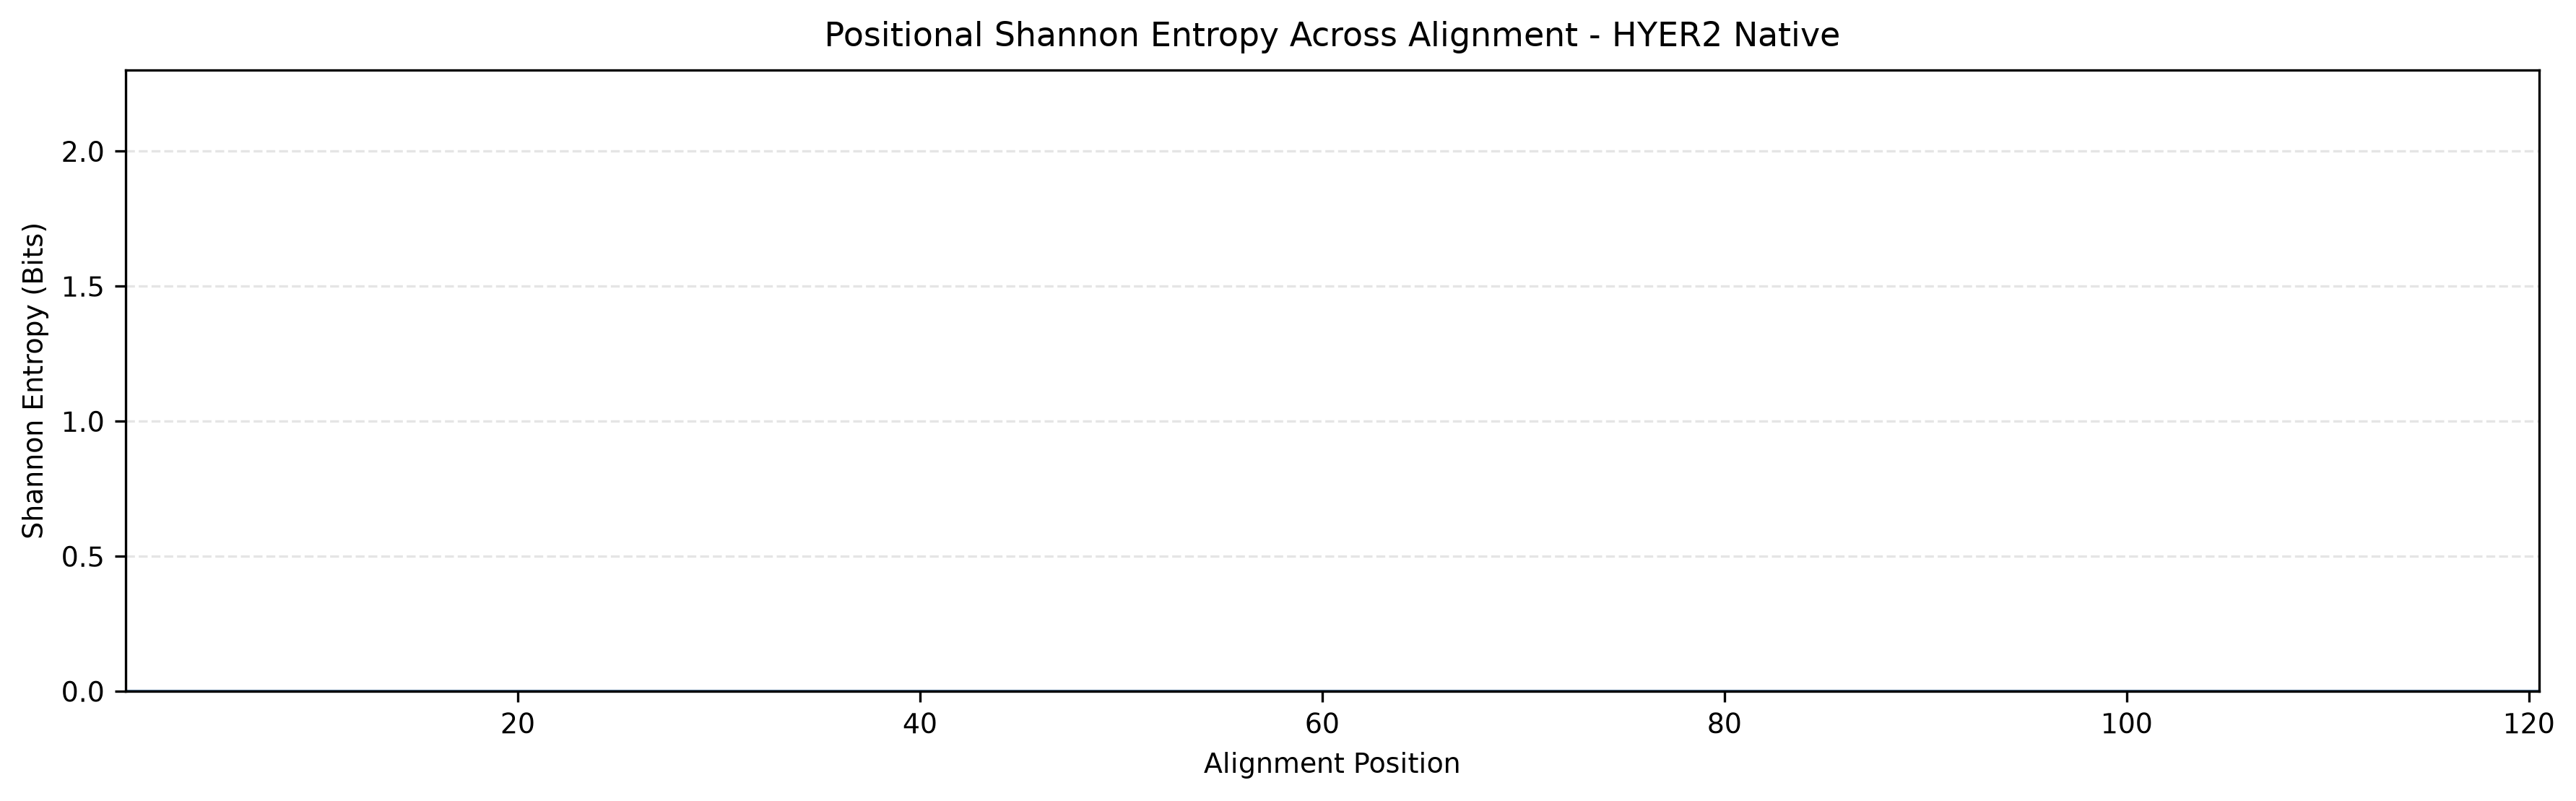

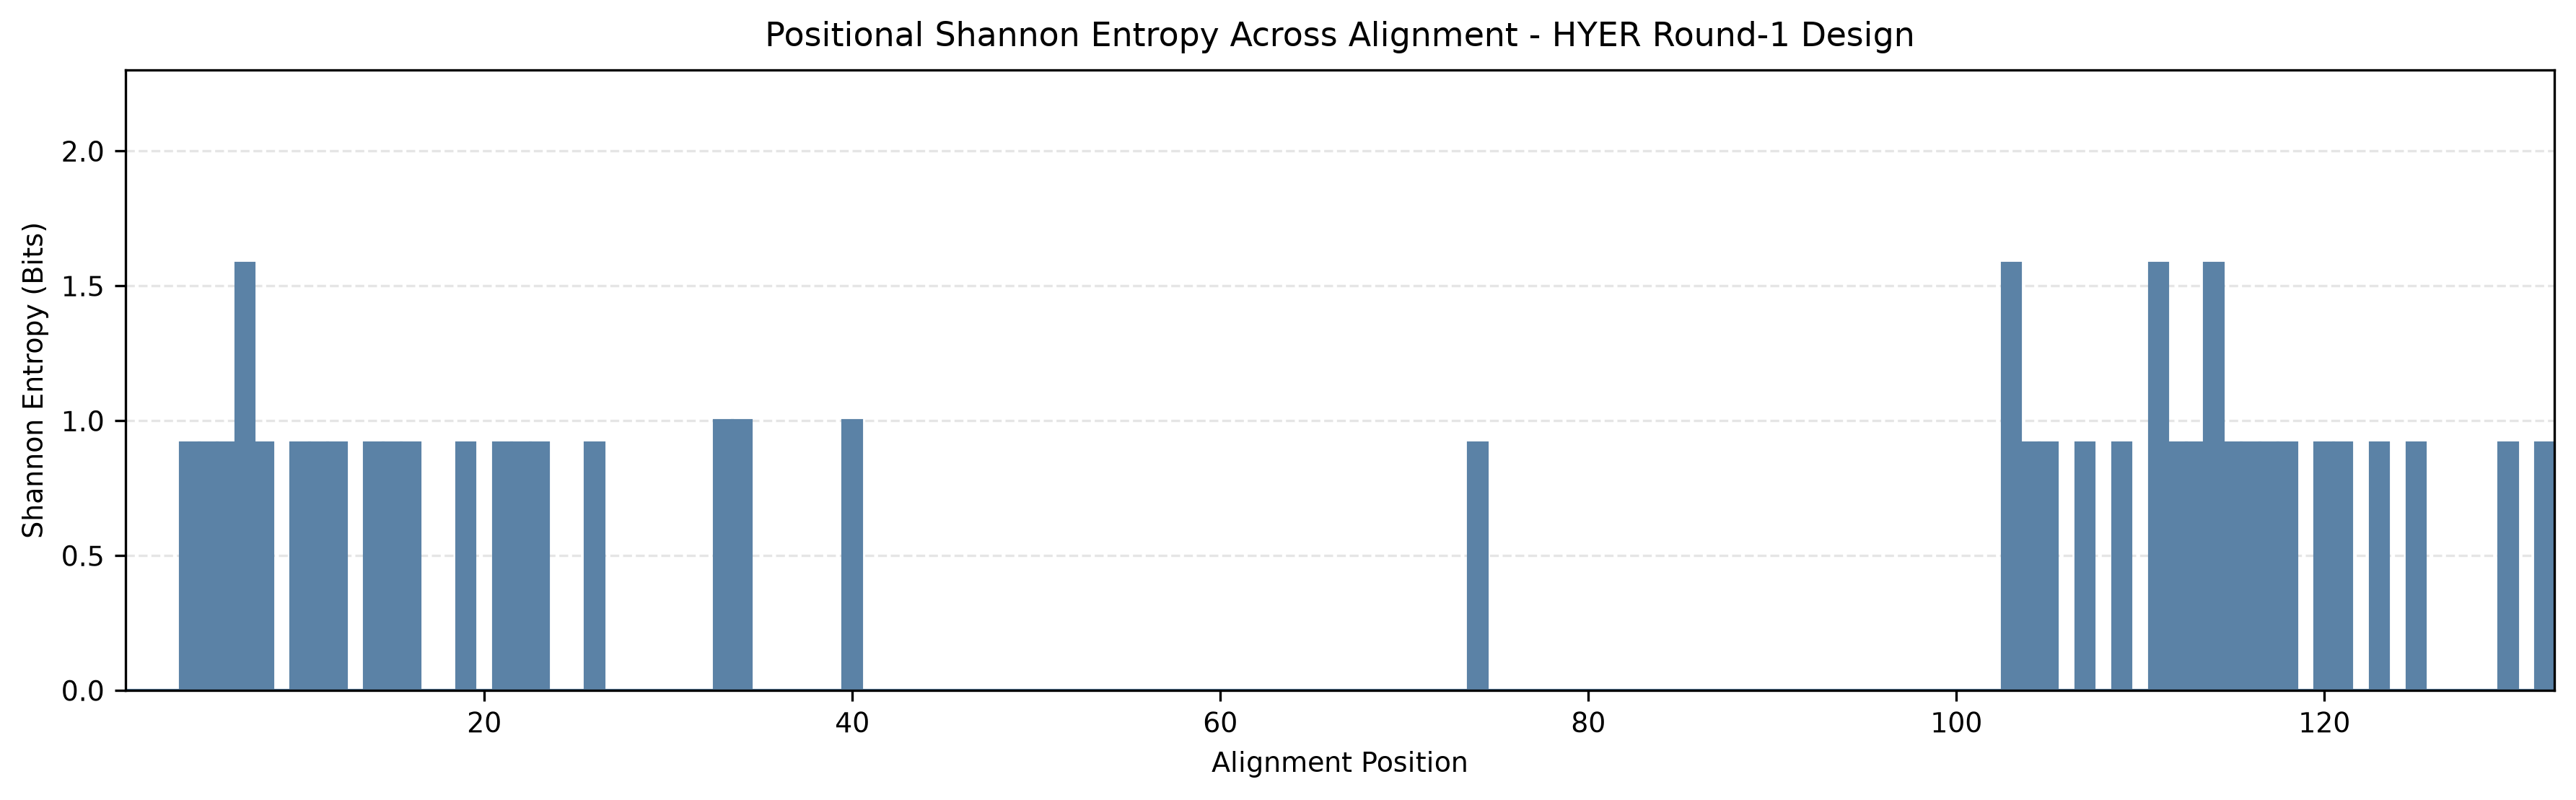

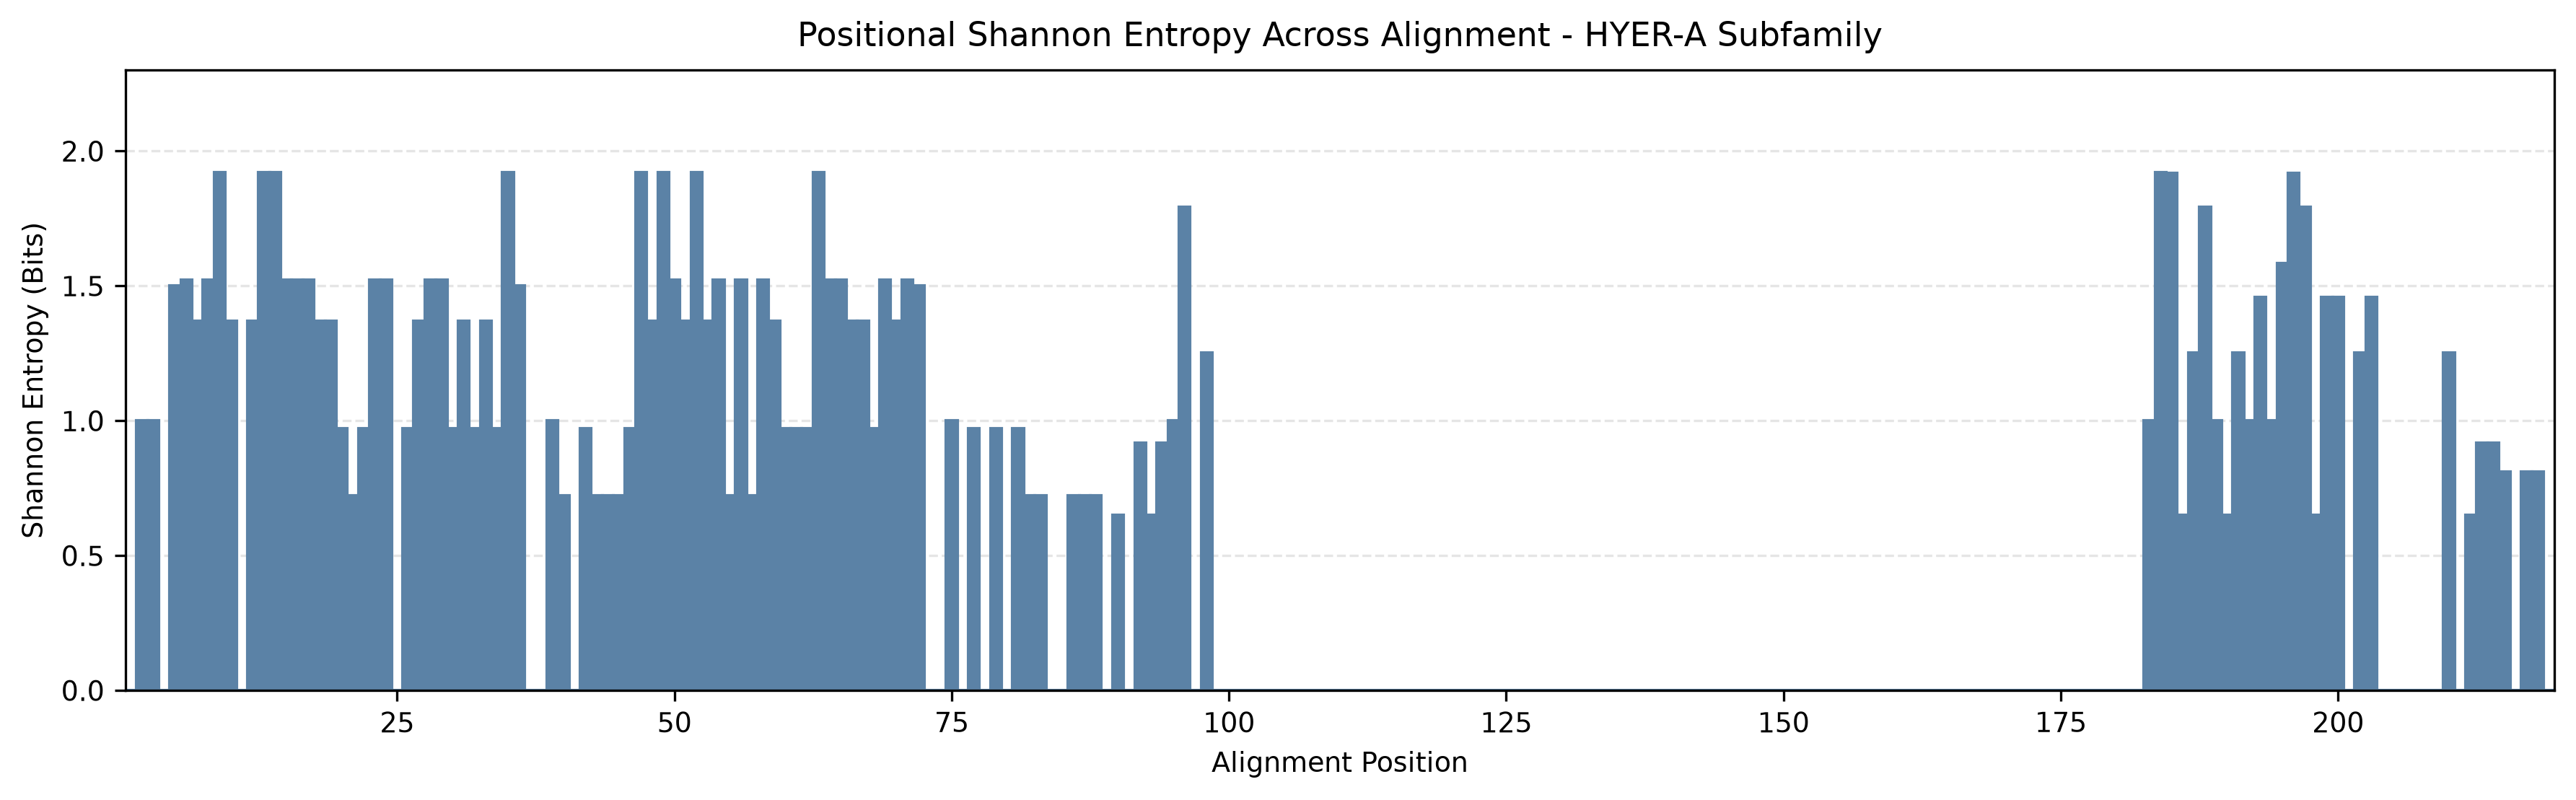

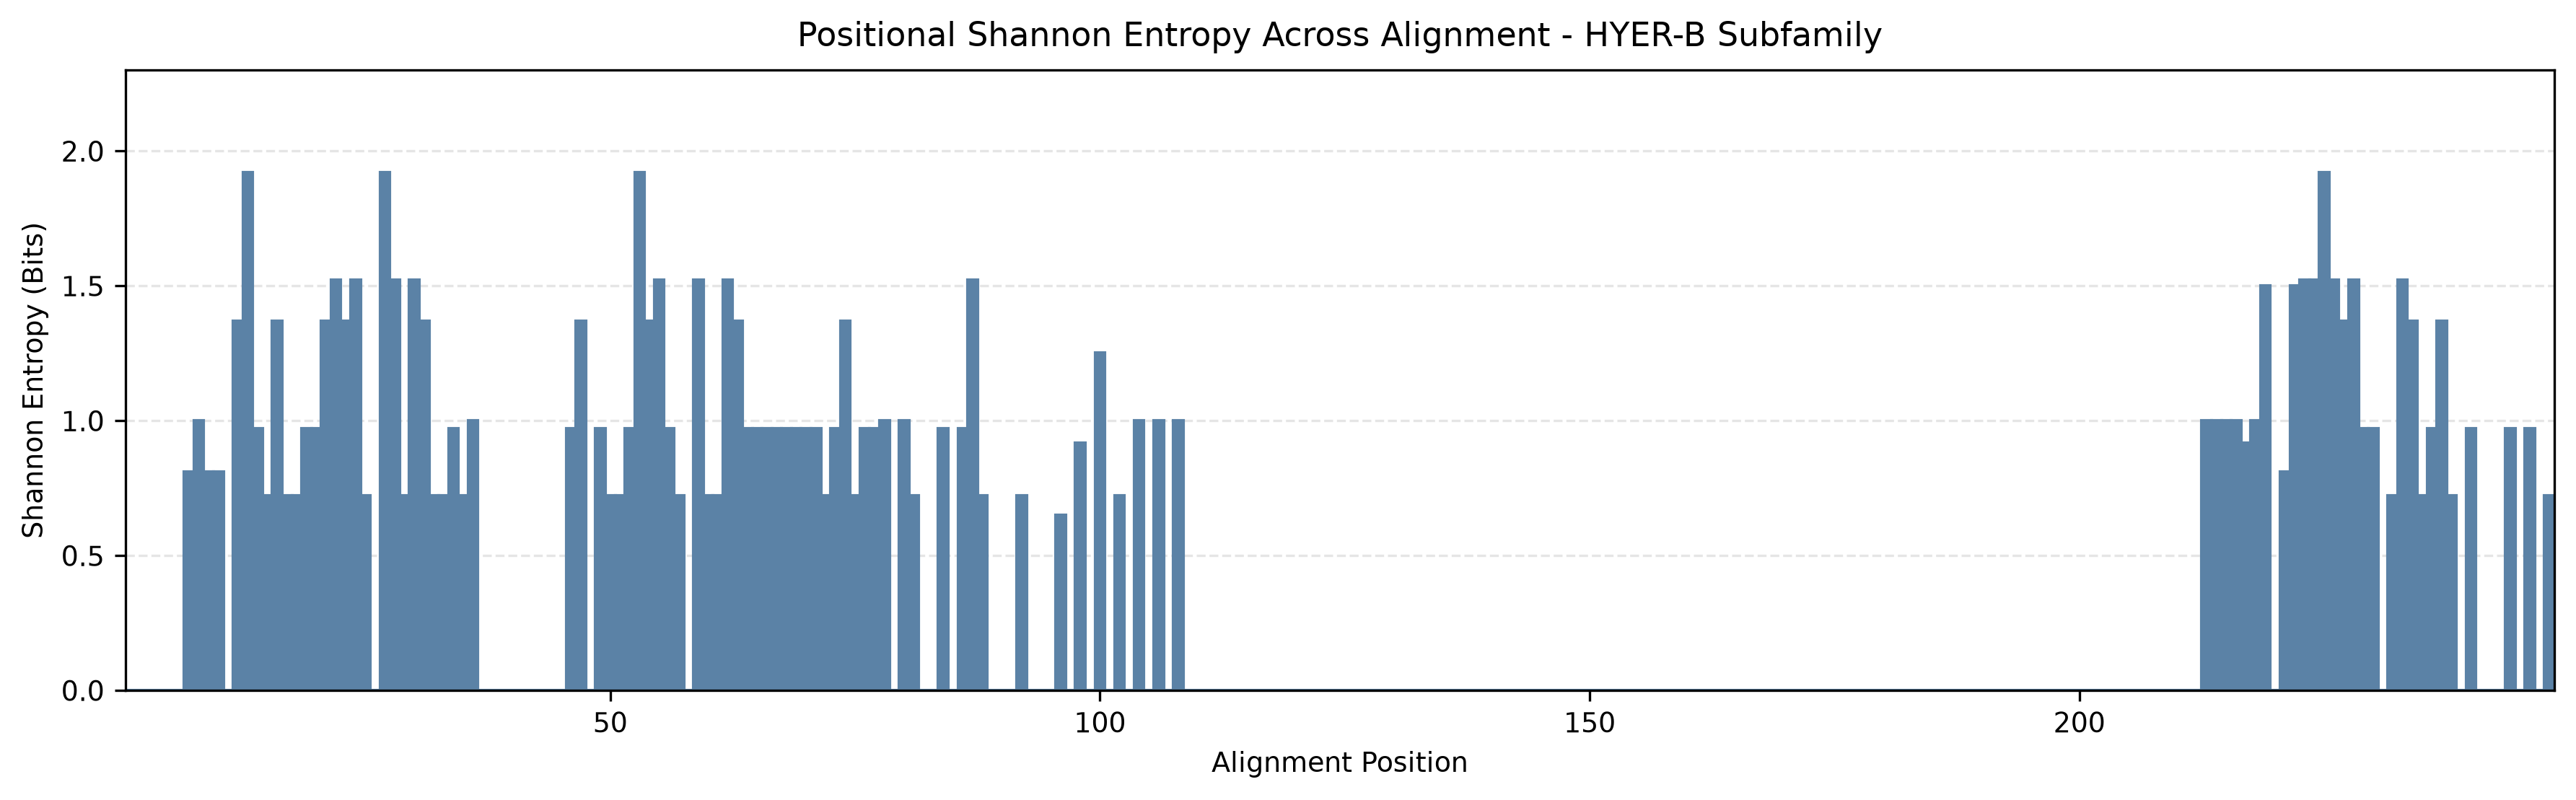

In [65]:
import matplotlib.pyplot as plt

# Loop through each HYER subfamily and plot positional entropy
for group_name, entropy_data in entropy_results.items():
    plt.figure(figsize=(12, 3.8), dpi=300)
    
    # 1-indexed alignment column positions
    positions = range(1, len(entropy_data) + 1)
    
    # Bar chart representing entropy at each position
    plt.bar(
        positions, 
        entropy_data, 
        width=1.0, 
        color="#5B82A6", 
        edgecolor="#5B82A6",
        align="center"
    )
    
    plt.xlabel("Alignment Position", fontsize=9)
    plt.ylabel("Shannon Entropy (Bits)", fontsize=9)
    plt.title(f"Positional Shannon Entropy Across Alignment - {group_name}", fontsize=11, pad=8)
    
    # Set y-axis limit to accommodate standard max entropy (~2.0 bits)
    plt.ylim(0, 2.3)
    plt.xlim(0.5, len(entropy_data) + 0.5)
    
    # Dashed light-gray horizontal gridlines behind bars
    plt.grid(axis="y", linestyle="--", alpha=0.5, color="#CCCCCC")
    plt.gca().set_axisbelow(True)
    plt.tick_params(axis="both", which="major", labelsize=9)
    
    plt.tight_layout()
    plt.show()

In [69]:
import pandas as pd

rows = []

for name, data in entropy_results.items():
    for pos, ent in enumerate(data, start=1):
        rows.append({
            "Class": name,
            "Position": pos,
            "Entropy": ent
        })

df = pd.DataFrame(rows)
df.to_csv("all_HYER_entropy.csv", index=False)

# Posterior Probability

In [66]:
import os
import io
import numpy as np
import pandas as pd

base_dir = os.path.expanduser("~/Desktop/HYER")
stk_file = os.path.join(base_dir, "HYER_16_self_aligned.stk")

# Map Infernal Stockholm PP characters to probabilities
pp_map = {
    '*': 0.975, '9': 0.90, '8': 0.80, '7': 0.70,
    '6': 0.60,  '5': 0.50, '4': 0.40, '3': 0.30,
    '2': 0.20,  '1': 0.10, '0': 0.05, '.': np.nan  # Gaps ignored
}

# sequence IDs to HYER subfamilies
tsv_data = """CL0105	HYER2_native_T7_IVT_gBlock	CL0106	CL0107	GUACGACGGG...
CL0115	HYER round-1 design (no Notes in sheet)	CL0118	CL0119	GGUGCGCCAG...
CL0116	HYER round-1 design (no Notes in sheet)	CL0118	CL0120	GGUGCGCCAG...
CL0117	HYER round-1 design (no Notes in sheet)	CL0118	CL0121	GGUGCGCCAG...
CL0154	HYER_A1_root8_t1_s2_TRSgraft	CL0134	CL0142	GGUGUGCCGG...
CL0155	HYER_A2_root5_t3_s1_TRSgraft	CL0135	CL0143	GGUGCGCCCG...
CL0156	HYER_A3_root3_t3_s1_TRSgraft	CL0135	CL0144	GGUGCGCCCG...
CL0157	HYER_A4_root10_t3_s4_TRSgraft	CL0136	CL0145	GGUACGCCAG...
CL0158	HYER_A5_root11_t4_s1_TRSgraft	CL0137	CL0146	GGCAAGCCCG...
CL0159	HYER_A6_root7_t4_s0_TRSgraft	CL0138	CL0147	GGCACACCCA...
CL0160	HYER_B1_root2_t1_s5	CL0135	CL0148	GGUGCGCCCG...
CL0161	HYER_B2_root8_t1_s5	CL0134	CL0149	GGUGUGCCGG...
CL0162	HYER_B3_root8_t1_s1	CL0134	CL0150	GGUGUGCCGG...
CL0163	HYER_B4_root2_t3_s3	CL0139	CL0151	GGUACGCCCG...
CL0164	HYER_B5_root7_t3_s2	CL0140	CL0152	GGUACGCCC...
CL0165	HYER_B6_root9_t5_s4	CL0141	CL0153	GGCAGGCUAG..."""

tsv_df = pd.read_csv(io.StringIO(tsv_data), sep="\t", header=None)
id_to_family = {}

for _, row in tsv_df.iterrows():
    seq_id, name_str = row[0], row[1]
    if "HYER_A" in name_str:
        id_to_family[seq_id] = "HYER-A Subfamily"
    elif "HYER_B" in name_str:
        id_to_family[seq_id] = "HYER-B Subfamily"
    elif "round-1" in name_str:
        id_to_family[seq_id] = "HYER Round-1 Design"
    elif "HYER2" in name_str:
        id_to_family[seq_id] = "HYER2 Native"
    else:
        id_to_family[seq_id] = "Other HYER"

# Extract #=GR <seq_id> PP annotations from master Stockholm file
pp_dict = {}
with open(stk_file, "r") as f:
    for line in f:
        if line.startswith("#=GR"):
            parts = line.split()
            # Expecting format: #=GR <seq_id> PP <pp_string>
            if len(parts) >= 4 and parts[2] == "PP":
                seq_id, pp_str = parts[1], parts[3]
                pp_dict[seq_id] = pp_dict.get(seq_id, "") + pp_str

# Group PP strings by HYER subfamily
grouped_pp = {}
for seq_id, pp_str in pp_dict.items():
    group_name = "Unassigned"
    for cl_id, family in id_to_family.items():
        if cl_id in seq_id:
            group_name = family
            break
            
    if group_name not in grouped_pp:
        grouped_pp[group_name] = {}
    grouped_pp[group_name][seq_id] = pp_str

# Calculate mean posterior probability per sequence (row) per HYER subfamily
row_pp_results = {}

for group_name, seq_pp_map in grouped_pp.items():
    mean_scores = []
    for seq_id, pp_str in seq_pp_map.items():
        # Convert PP characters to numeric probabilities
        scores = [pp_map[char] for char in pp_str if char in pp_map]
        valid_scores = [s for s in scores if not np.isnan(s)]
        
        if valid_scores:
            mean_scores.append(np.mean(valid_scores))

    row_pp_results[group_name] = np.array(mean_scores)
    
    if len(mean_scores) > 0:
        print(f"{group_name}: Processed {len(mean_scores)} sequence scores (Mean fit: {np.mean(mean_scores):.3f})")
    else:
        print(f"Warning: No valid PP scores extracted for {group_name}")

HYER2 Native: Processed 1 sequence scores (Mean fit: 0.776)
HYER Round-1 Design: Processed 3 sequence scores (Mean fit: 0.808)
HYER-A Subfamily: Processed 6 sequence scores (Mean fit: 0.809)
HYER-B Subfamily: Processed 6 sequence scores (Mean fit: 0.856)


HYER2 Native: Processed 1 sequence scores (Mean fit: 0.776)


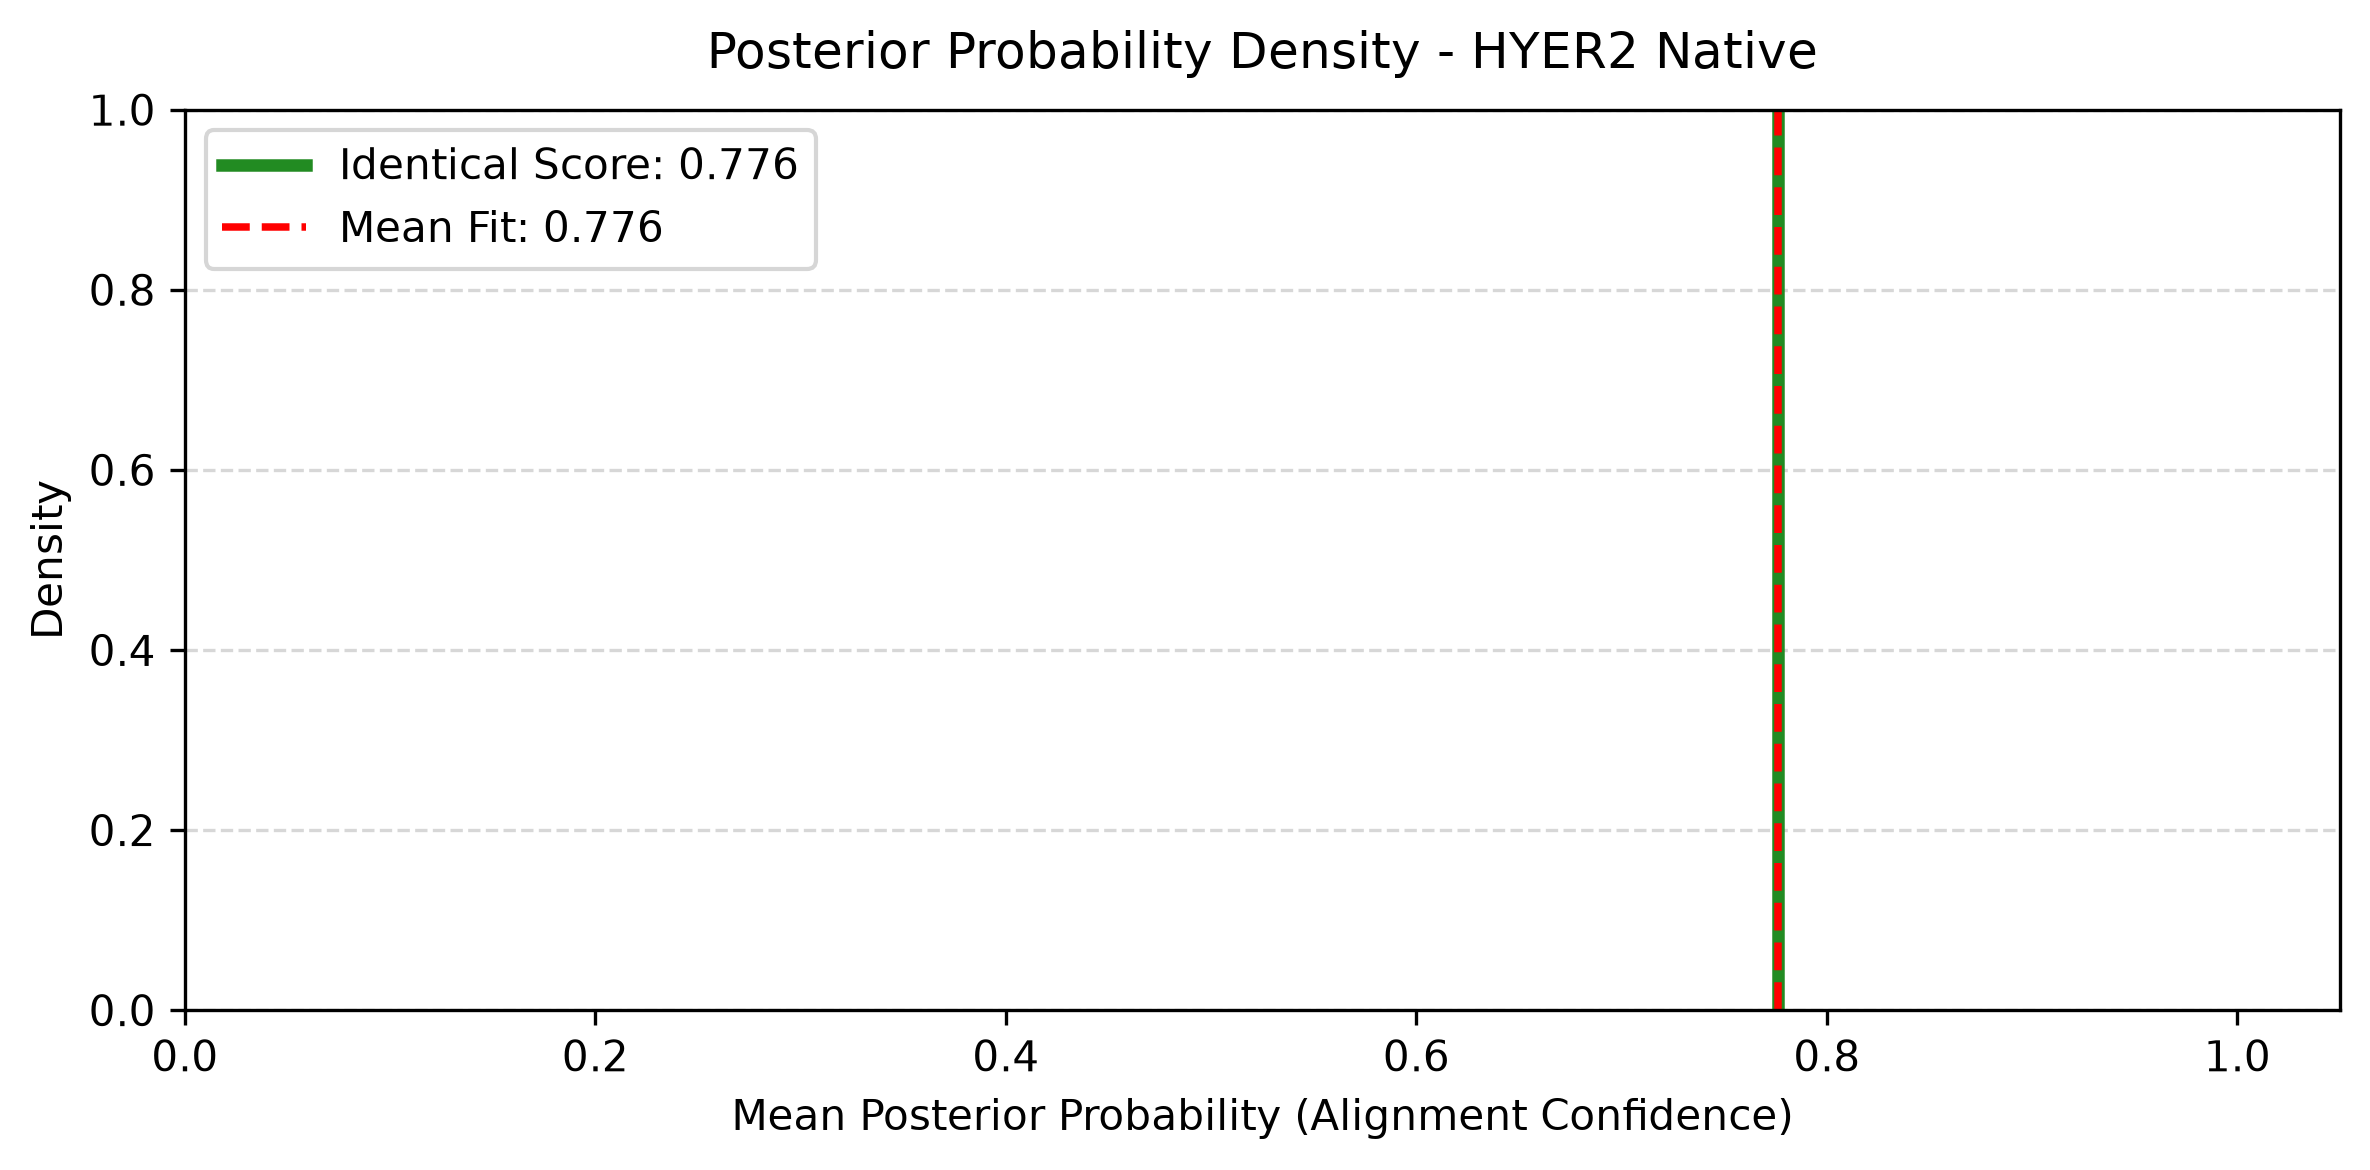

HYER Round-1 Design: Processed 3 sequence scores (Mean fit: 0.808)


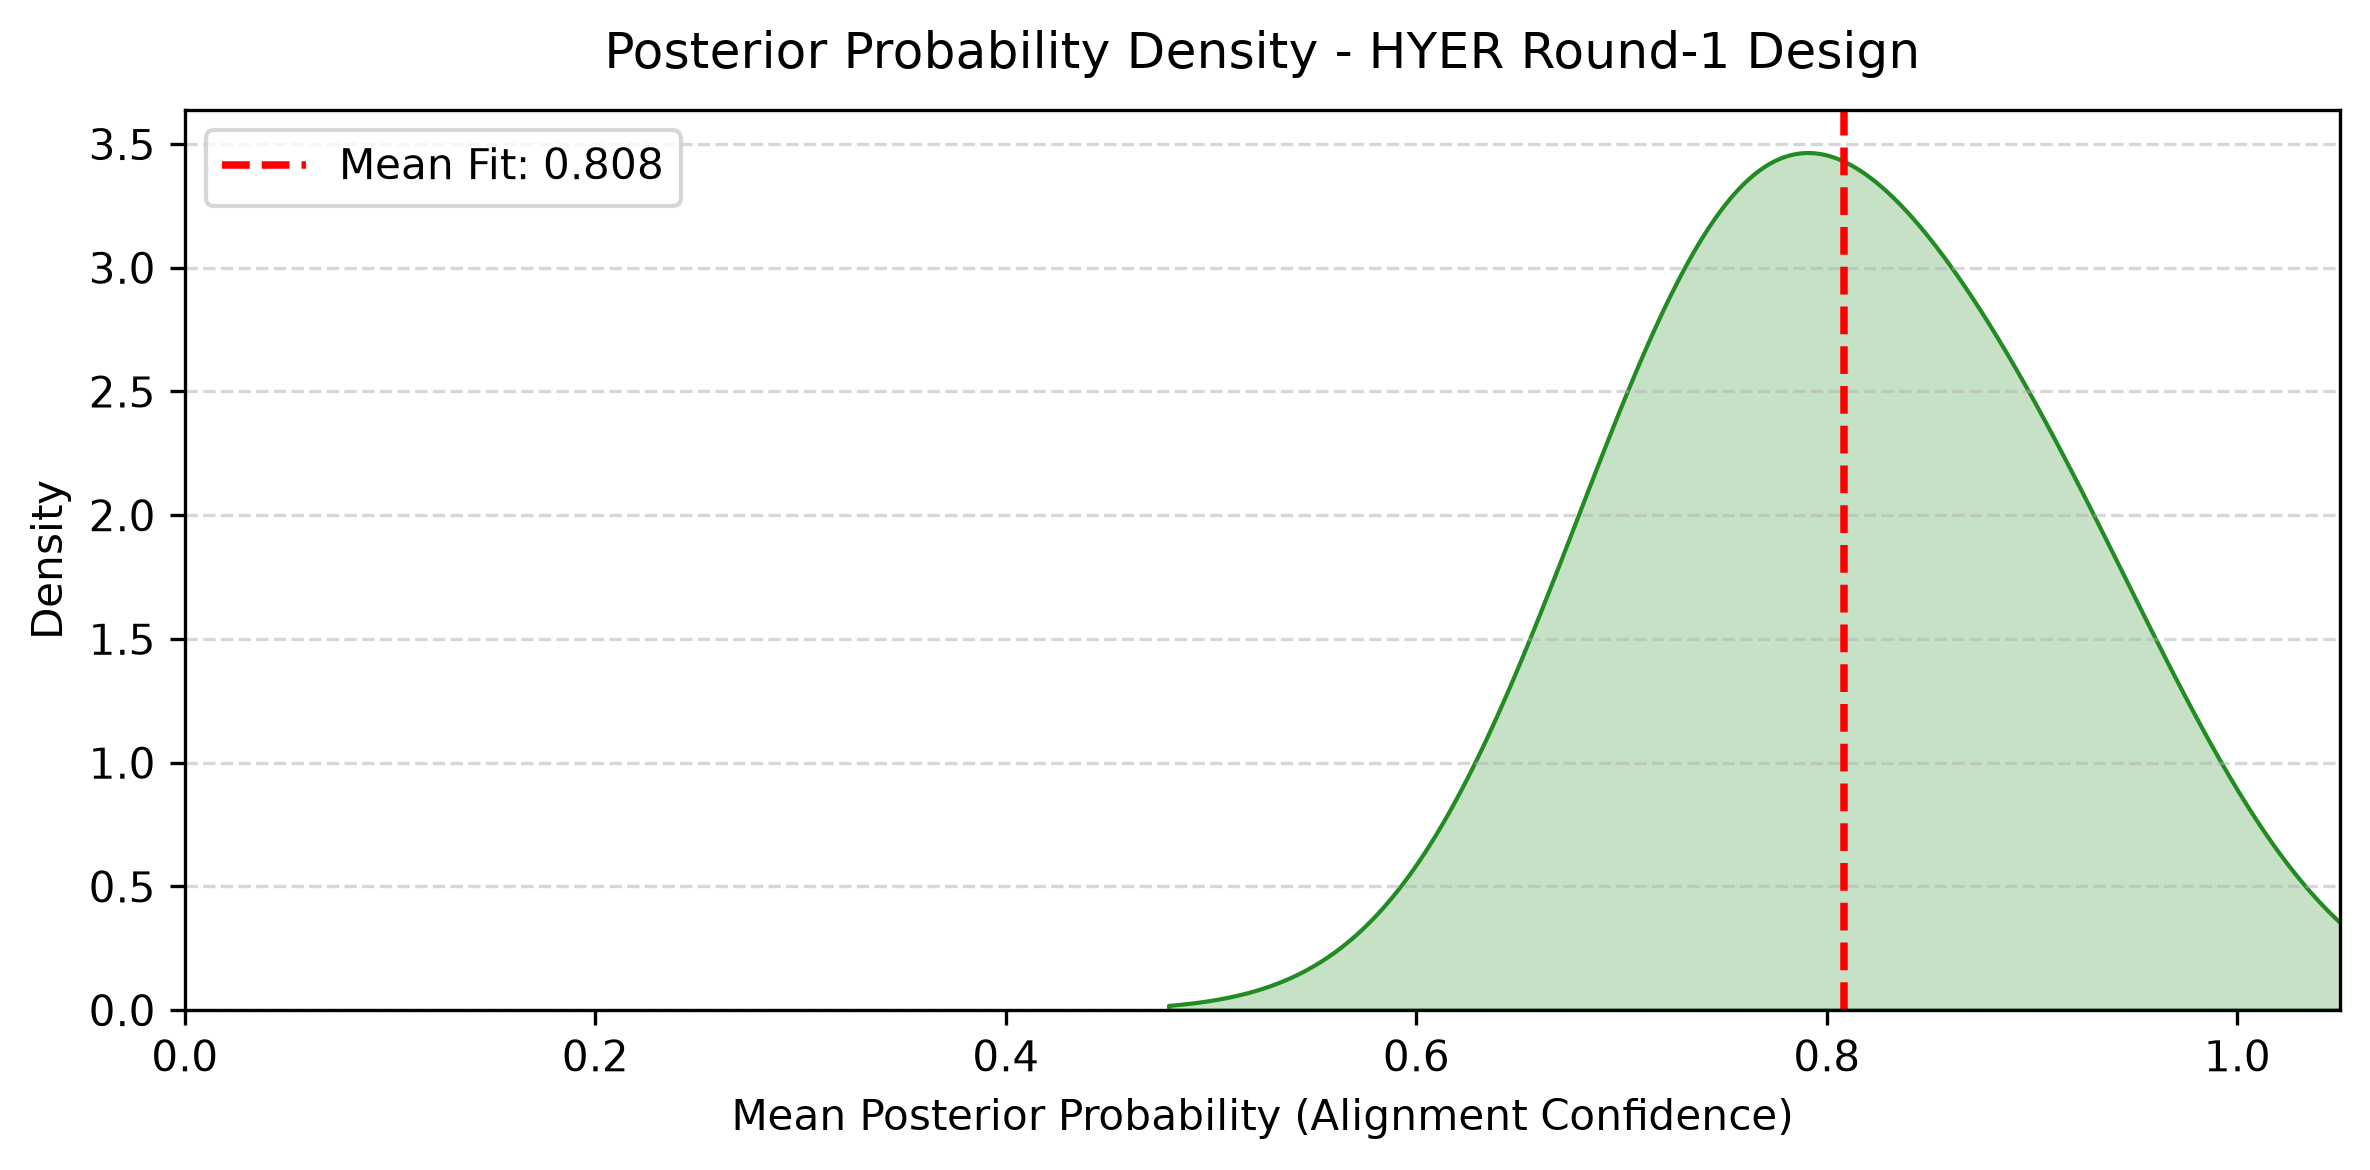

HYER-A Subfamily: Processed 6 sequence scores (Mean fit: 0.809)


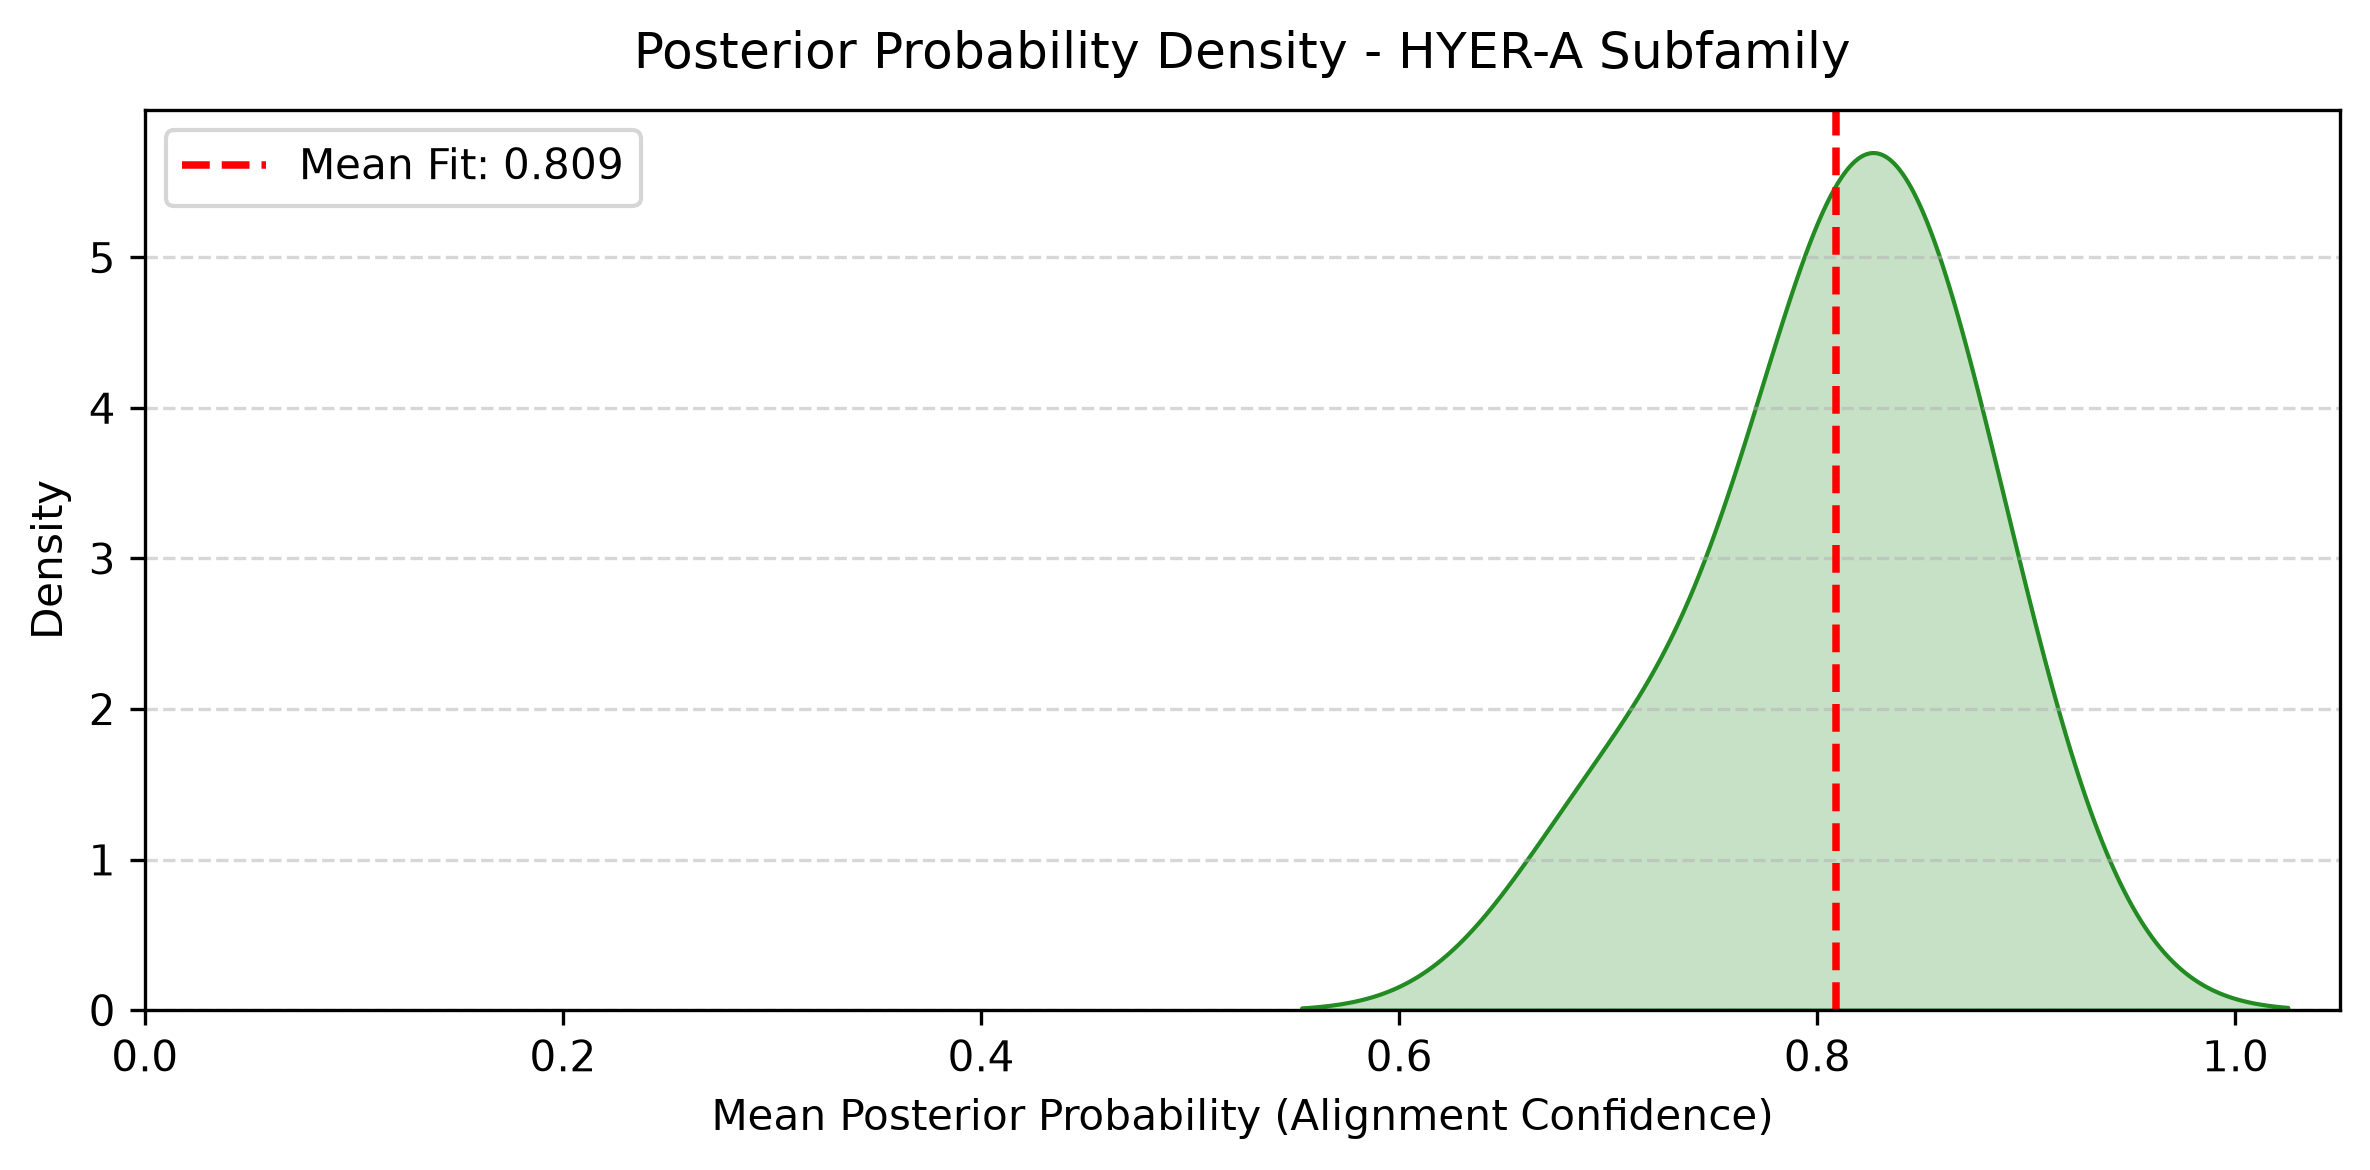

HYER-B Subfamily: Processed 6 sequence scores (Mean fit: 0.856)


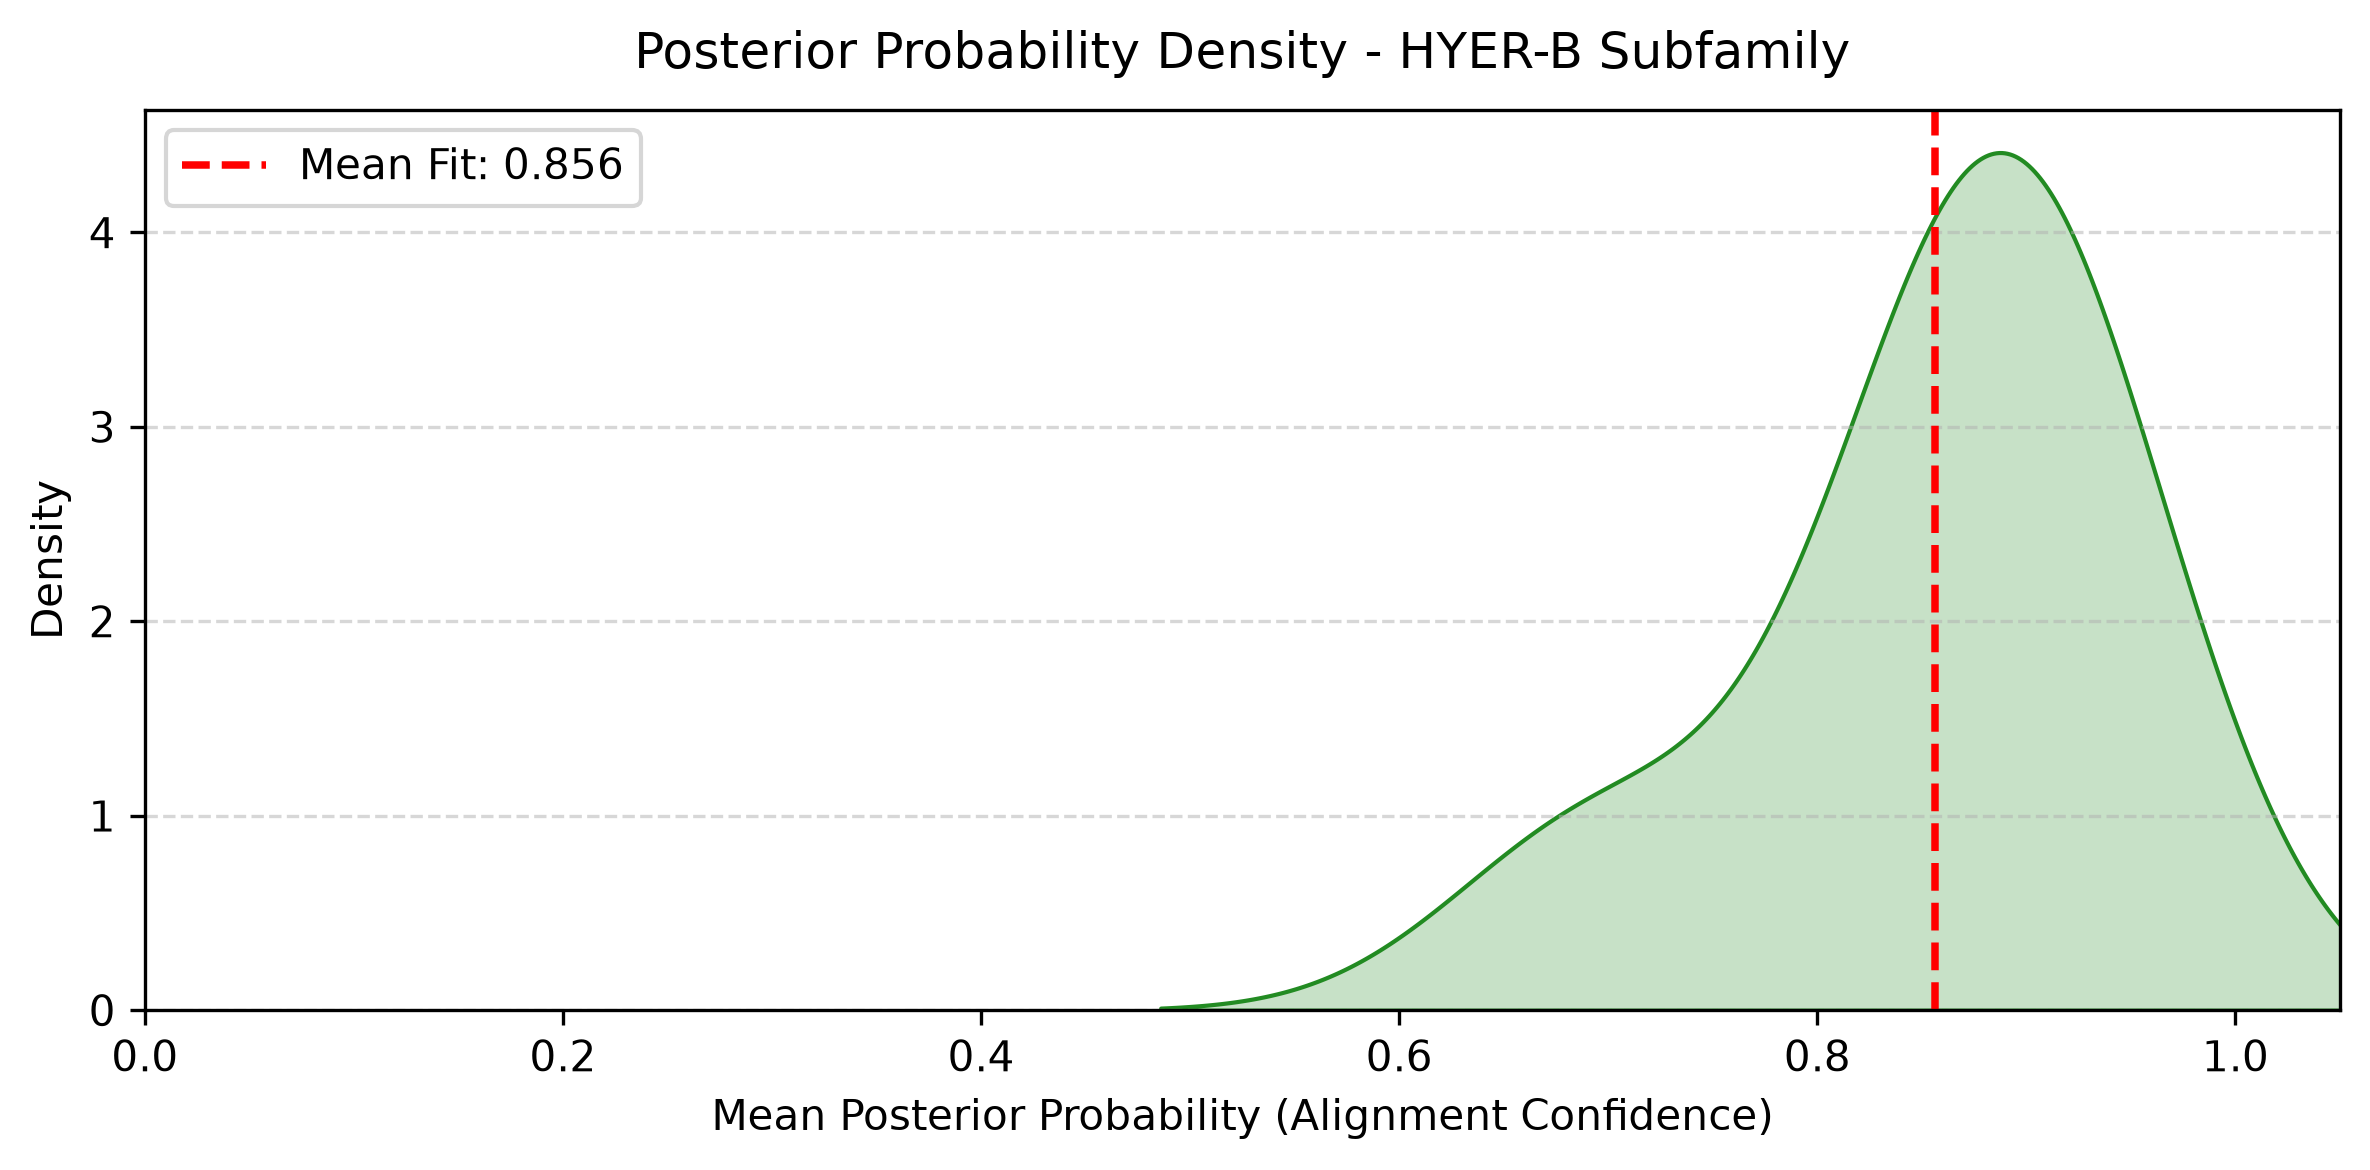

In [68]:
import os
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

base_dir = os.path.expanduser("~/Desktop/HYER")
stk_file = os.path.join(base_dir, "HYER_16_self_aligned.stk")

# Map Infernal Stockholm PP characters to probabilities (ignoring gaps ".")
pp_map = {
    '*': 0.975, '9': 0.90, '8': 0.80, '7': 0.70,
    '6': 0.60,  '5': 0.50, '4': 0.40, '3': 0.30,
    '2': 0.20,  '1': 0.10, '0': 0.05, '.': np.nan
}

# sequence IDs to HYER subfamilies
tsv_data = """CL0105	HYER2_native_T7_IVT_gBlock	CL0106	CL0107	GUACGACGGG...
CL0115	HYER round-1 design (no Notes in sheet)	CL0118	CL0119	GGUGCGCCAG...
CL0116	HYER round-1 design (no Notes in sheet)	CL0118	CL0120	GGUGCGCCAG...
CL0117	HYER round-1 design (no Notes in sheet)	CL0118	CL0121	GGUGCGCCAG...
CL0154	HYER_A1_root8_t1_s2_TRSgraft	CL0134	CL0142	GGUGUGCCGG...
CL0155	HYER_A2_root5_t3_s1_TRSgraft	CL0135	CL0143	GGUGCGCCCG...
CL0156	HYER_A3_root3_t3_s1_TRSgraft	CL0135	CL0144	GGUGCGCCCG...
CL0157	HYER_A4_root10_t3_s4_TRSgraft	CL0136	CL0145	GGUACGCCAG...
CL0158	HYER_A5_root11_t4_s1_TRSgraft	CL0137	CL0146	GGCAAGCCCG...
CL0159	HYER_A6_root7_t4_s0_TRSgraft	CL0138	CL0147	GGCACACCCA...
CL0160	HYER_B1_root2_t1_s5	CL0135	CL0148	GGUGCGCCCG...
CL0161	HYER_B2_root8_t1_s5	CL0134	CL0149	GGUGUGCCGG...
CL0162	HYER_B3_root8_t1_s1	CL0134	CL0150	GGUGUGCCGG...
CL0163	HYER_B4_root2_t3_s3	CL0139	CL0151	GGUACGCCCG...
CL0164	HYER_B5_root7_t3_s2	CL0140	CL0152	GGUACGCCC...
CL0165	HYER_B6_root9_t5_s4	CL0141	CL0153	GGCAGGCUAG..."""

tsv_df = pd.read_csv(io.StringIO(tsv_data), sep="\t", header=None)
id_to_family = {}

for _, row in tsv_df.iterrows():
    seq_id, name_str = row[0], row[1]
    if "HYER_A" in name_str:
        id_to_family[seq_id] = "HYER-A Subfamily"
    elif "HYER_B" in name_str:
        id_to_family[seq_id] = "HYER-B Subfamily"
    elif "round-1" in name_str:
        id_to_family[seq_id] = "HYER Round-1 Design"
    elif "HYER2" in name_str:
        id_to_family[seq_id] = "HYER2 Native"
    else:
        id_to_family[seq_id] = "Other HYER"

# Extract #=GR <seq_id> PP annotations from master Stockholm file
pp_dict = {}
with open(stk_file, "r") as f:
    for line in f:
        if line.startswith("#=GR"):
            parts = line.split()
            if len(parts) >= 4 and parts[2] == "PP":
                seq_id, pp_str = parts[1], parts[3]
                # Concatenate PP strings across multiple alignment blocks
                pp_dict[seq_id] = pp_dict.get(seq_id, "") + pp_str

# Group PP strings by HYER subfamily
grouped_pp = {}
for seq_id, pp_str in pp_dict.items():
    group_name = "Unassigned"
    for cl_id, family in id_to_family.items():
        if cl_id in seq_id:
            group_name = family
            break
            
    if group_name not in grouped_pp:
        grouped_pp[group_name] = {}
    grouped_pp[group_name][seq_id] = pp_str

# Process scores and generate separate figures per HYER subfamily
row_pp_results = {}

for group_name, seq_pp_map in grouped_pp.items():
    mean_scores = []
    
    for seq_id, pp_str in seq_pp_map.items():
        scores = [pp_map[char] for char in pp_str if char in pp_map]
        valid_scores = [s for s in scores if not np.isnan(s)]
        if valid_scores:
            mean_scores.append(np.mean(valid_scores))

    row_pp_results[group_name] = np.array(mean_scores)
    
    if mean_scores:
        group_mean = np.mean(mean_scores)
        print(f"{group_name}: Processed {len(mean_scores)} sequence scores (Mean fit: {group_mean:.3f})")
        
        plt.figure(figsize=(8, 4), dpi=300)
        
        # Plot KDE if variance exists and n > 1; otherwise plot a vertical bar
        if len(mean_scores) > 1 and np.var(mean_scores) > 0:
            sns.kdeplot(
                mean_scores, 
                color="forestgreen", 
                fill=True, 
                bw_adjust=1.2, 
                gridsize=500,
                warn_singular=False
            )
        else:
            plt.axvline(
                x=group_mean,
                color="forestgreen",
                linewidth=3,
                label=f"Identical Score: {group_mean:.3f}"
            )
        
        # Red dashed reference line for the mean fit
        plt.axvline(
            x=group_mean, 
            color="red", 
            linestyle="--", 
            linewidth=1.8,
            label=f"Mean Fit: {group_mean:.3f}"
        )
        
        plt.xlabel("Mean Posterior Probability (Alignment Confidence)", fontsize=10)
        plt.ylabel("Density", fontsize=10)
        plt.title(f"Posterior Probability Density - {group_name}", fontsize=12, pad=10)
        plt.xlim(0, 1.05)
        plt.legend(loc="upper left", frameon=True)
        plt.grid(axis="y", linestyle="--", alpha=0.5)
        plt.tight_layout()
        plt.show()
    else:
        print(f"{group_name}: No valid posterior probability (#=GR PP) lines found.")

In [70]:
import pandas as pd

rows = []

for base_name, scores in row_pp_results.items():
    for i, score in enumerate(scores, start=1):
        rows.append({
            "Class": base_name,
            "Sequence_Index": i,
            "Mean_Posterior_Probability": score
        })

df = pd.DataFrame(rows)
df.to_csv("all_HYER_mean_pp_scores.csv", index=False)

# (Ignore Below this) Trying diff Group II Introns as reference

Group II introns carry their most strictly conserved sequence and secondary structure in Domain 5 (hairpin) ([Qu et al., 2016](https://pmc.ncbi.nlm.nih.gov/articles/PMC4899178/)). Try using only that part of the sequences from Rfam Group II introns; DV DVI

In [32]:
# group group-II-D1D4-3 (RF02001) reference for alignment ?
# can i use this as a ref when i want to align the seq i have against it?  
!curl -s "https://rfam.org/family/RF00029/cm" -o RF00029.cm

!head -n 10 RF00029.cm

INFERNAL1/a [1.1.4 | Dec 2020]
NAME     Intron_gpII
ACC      RF00029
DESC     Group II catalytic intron
STATES   240
NODES    64
CLEN     77
W        476
ALPH     RNA
RF       no


ended up all negative bit scores for each of the 16 seq

In [120]:
import os
import subprocess
import urllib.request
import pandas as pd

# Paths
base_dir = os.path.expanduser("~/Desktop/HYER")
fasta_dir = os.path.join(base_dir, "HYER_fasta_files")
output_dir = os.path.join(base_dir, "group_ii_benchmark")

os.makedirs(output_dir, exist_ok=True)

# 1. Extract 3' end slice (last 120 nt) of Native CL0105
native_file = os.path.join(fasta_dir, "CL0105_HYER2_native_T7_IVT_gBlock.fa")
if not os.path.exists(native_file):
    native_file = os.path.join(fasta_dir, "CL0105_HYER2_native_T7_IVT_gBlock.fasta")

d56_slice_fasta = os.path.join(output_dir, "CL0105_D56_slice.fasta") #output

with open(native_file, "r") as f: # open in read mode, auto close when done
    lines = [l.strip() for l in f if l.strip()] # read all lines, strip white space and ignore blank lines
    header = lines[0]
    seq = "".join(lines[1:]) # makes one continuous seq of nt

d56_seq = seq[-120:] # only include last 120 nt up to 3' end

with open(d56_slice_fasta, "w") as f: # open in write mode
    f.write(f"{header}_D56_slice\n{d56_seq}\n") # new FASTA header, 120 nt portion on new line

print(f"Sliced D5/6 fragment ({len(d56_seq)} nt) saved to {d56_slice_fasta}\n")

# 2. Potential Group II Intron references from Rfam
group_ii_families = {
    "RF02001": "Group_II_D5_D6",
    "RF00029": "Group_II_intron",
    "RF01998": "Group_IIA_intron",
    "RF01999": "Group_IIC_intron"
}

results = []

# 3. Screen D5/6 only, across all candidate models
for acc, name in group_ii_families.items():
    ref_cm = os.path.join(output_dir, f"{acc}_ref.cm")
    scores_file = os.path.join(output_dir, f"{acc}_slice_scores.txt") # output for cmalign table
    aligned_stk = os.path.join(output_dir, f"{acc}_slice_aligned.stk")
    
    if not os.path.exists(ref_cm): # cm present?
        print(f"Downloading {acc} model...")
        url = f"https://rfam.org/family/{acc}/cm"
        urllib.request.urlretrieve(url, ref_cm) # fetch cm directly from Rfam
        
    if os.path.exists(scores_file):
        os.remove(scores_file)

    cmd = [
        "cmalign",
        "--outformat", "Stockholm",
        "-o", aligned_stk,
        "--sfile", scores_file,
        ref_cm,
        d56_slice_fasta
    ]
    subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)
    
    if os.path.exists(scores_file): # verify that cm was built
        with open(scores_file, "r") as sf:
            for line in sf:
                if line.startswith("#") or line.startswith("//") or not line.strip():
                    continue
                parts = line.split()
                # Ensure it's a valid data row (starts with index number)
                if len(parts) >= 8 and parts[0].isdigit():
                    try:
                        bit_score = float(parts[6])
                        avg_pp = float(parts[7])
                        results.append({
                            "Rfam_Accession": acc,
                            "Family_Name": name,
                            "Bit_Score": bit_score,
                            "Avg_PP": avg_pp,
                            "CM_From": parts[3],
                            "CM_To": parts[4]
                        })
                    except ValueError:
                        continue

df = pd.DataFrame(results).sort_values(by="Bit_Score", ascending=False)

print("="*65)
print(" D5/6 FRAGMENT BENCHMARK RESULTS")
print("="*65)
print(df.to_string(index=False))

best_ref = df.iloc[0]["Rfam_Accession"]
print(f"\nTop performing reference model: {best_ref}")

Sliced D5/6 fragment (120 nt) saved to /Users/vickic/Desktop/HYER/group_ii_benchmark/CL0105_D56_slice.fasta

 D5/6 FRAGMENT BENCHMARK RESULTS
Rfam_Accession      Family_Name  Bit_Score  Avg_PP CM_From CM_To
       RF00029  Group_II_intron       2.10   0.601      22    77
       RF01999 Group_IIC_intron     -10.61   0.576       3   111
       RF02001   Group_II_D5_D6     -16.15   0.651      35   156
       RF01998 Group_IIA_intron     -17.97   0.907      39    47

Top performing reference model: RF00029


In [24]:
import os
import subprocess

# Paths
base_dir = os.path.expanduser("~/Desktop/HYER")
all_fasta = os.path.join(base_dir, "HYER_sequences.fasta")
output_dir = os.path.join(base_dir, "group_ii_benchmark")

# RF00029 best reference
best_ref_cm = os.path.join(output_dir, "RF00029_ref.cm") 

master_stk = os.path.join(base_dir, "HYER_16_aligned_master.stk")
native_cm = os.path.join(base_dir, "HYER_native.cm")
self_aligned_stk = os.path.join(base_dir, "HYER_16_self_aligned.stk")
final_scores = os.path.join(base_dir, "HYER_native_scores.txt")

# Create 3' sliced fasta for initial master alignment so that #1 below aligns our seq to the end of RF00029 instead of the start
# Since DV/VI are at the end of RF00029
sliced_fasta = os.path.join(base_dir, "HYER_16_D56_sliced.fasta")

with open(all_fasta, "r") as infile, open(sliced_fasta, "w") as outfile:
    current_header = ""
    current_seq = []
    for line in infile:
        line = line.strip()
        if line.startswith(">"):
            if current_header:
                seq_str = "".join(current_seq)
                outfile.write(f"{current_header}\n{seq_str[-120:]}\n")
            current_header = line
            current_seq = []
        else:
            current_seq.append(line)
    if current_header:
        seq_str = "".join(current_seq)
        outfile.write(f"{current_header}\n{seq_str[-120:]}\n")


# 1. cmalign: Align all 16 seq to RF00029 --> MSA
print("1. Aligning all 16 sequences to RF00029 reference model...")
cmd_align = [
    "cmalign",
    "--mxsize", "4096",
    "--outformat", "Stockholm",
    "-o", master_stk,
    best_ref_cm,
    sliced_fasta
]
subprocess.run(cmd_align, check=True)
print(f" -> Master Stockholm MSA saved: {master_stk}")

# 2. cmbuild: Take #1 output --> native cm
print("\n2. Building native HYER Covariance Model...")
cmd_build = ["cmbuild", "-F", native_cm, master_stk]
subprocess.run(cmd_build, check=True)
print(f" -> Native CM file created: {native_cm}")

# 3. Re-align sequences against native CM
print("\n3. Re-aligning constructs against HYER_native.cm...")
cmd_rescore = [
    "cmalign",
    "--outformat", "Stockholm",
    "-o", self_aligned_stk,
    "--sfile", final_scores,
    native_cm,
    sliced_fasta
]
subprocess.run(cmd_rescore, check=True)
print(f" -> Self-alignment complete: {self_aligned_stk}")
print(f" -> Final score report saved: {final_scores}")

1. Aligning all 16 sequences to RF00029 reference model...
# cmalign :: align sequences to a CM
# INFERNAL 1.1.5 (Sep 2023)
# Copyright (C) 2023 Howard Hughes Medical Institute.
# Freely distributed under the BSD open source license.
# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
# CM file:                                     /Users/vickic/Desktop/HYER/group_ii_benchmark/RF00029_ref.cm
# sequence file:                               /Users/vickic/Desktop/HYER/HYER_16_D56_sliced.fasta
# CM name:                                     Intron_gpII
# saving alignment to file:                    /Users/vickic/Desktop/HYER/HYER_16_aligned_master.stk
# maximum total DP matrix size set to:         4096.00 Mb
# number of worker threads:                    4
# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
#                                                                                                              running time (s)                 

1. Negative bit scores expected bc the HYER seq only match up to a portion of RF00029 (short cm). Moderate to high posterior probability: high confidence of base pairing in the small amount of alignments.
2. 656 consensus vs. 950 alignment length. 2 base pairs, 2 bifurcations. Relative entropy is non-zero = some conserved
3. calibrate
4. align original 16 sequences to the new HYER_native.cm from #2, so now compared to the negative bit scores of the RF00029 reference, they're positive and much higher. Average pp also went up, indicating more precise alignment.

In [131]:
# generate stk files from RF00029 as ref

import os
from Bio import AlignIO
from Bio.Align import MultipleSeqAlignment

base_dir = os.path.expanduser("~/Desktop/HYER")
self_aligned_stk = os.path.join(base_dir, "HYER_16_self_aligned.stk")
output_dir = os.path.join(base_dir, "individual_stk_files")

os.makedirs(output_dir, exist_ok=True)

# Read the full alignment
alignment = AlignIO.read(self_aligned_stk, "stockholm")

# Iterate over each sequence record and write to an individual Stockholm file
for record in alignment:
    # only ID for filename
    seq_id = record.id.split("/")[0]  # Remove positional tags if present
    out_path = os.path.join(output_dir, f"{seq_id}.stk")

    # Wrap the single record in a MultipleSeqAlignment object to preserve stk format
    single_seq_alignment = MultipleSeqAlignment([record])

    # Maintain global/consensus annotations if present (e.g., secondary structure)
    if hasattr(alignment, "annotations"):
        single_seq_alignment.annotations = alignment.annotations

    with open(out_path, "w") as out_f:
        AlignIO.write(single_seq_alignment, out_f, "stockholm")

print(
    f"Successfully saved {len(alignment)} individual Stockholm files to: {output_dir}"
)

Successfully saved 16 individual Stockholm files to: /Users/vickic/Desktop/HYER/individual_stk_files


In [25]:
# missing 2ndary structure annotations ? adding them

import os
from Bio import AlignIO
from Bio.Align import MultipleSeqAlignment

base_dir = os.path.expanduser("~/Desktop/HYER")
master_stk = os.path.join(base_dir, "HYER_16_self_aligned.stk")
stk_dir = os.path.join(base_dir, "HYER_stk")

os.makedirs(stk_dir, exist_ok=True)

# Parse master alignment
alignment = AlignIO.read(master_stk, "stockholm")

# Extract consensus secondary structure string if present
ss_cons = alignment.column_annotations.get("SS_cons", None)

for record in alignment:
    seq_id = record.id.split("/")[0]
    stk_path = os.path.join(stk_dir, f"{seq_id}.stk")

    # Create single-sequence alignment object
    single_alignment = MultipleSeqAlignment([record])

    # Re-attach secondary structure annotation
    if ss_cons:
        single_alignment.column_annotations["SS_cons"] = ss_cons

    with open(stk_path, "w") as out_f:
        AlignIO.write(single_alignment, out_f, "stockholm")

print(
    f"Re-exported {len(alignment)} .stk files WITH #=GC SS_cons"
)

Re-exported 16 .stk files WITH #=GC SS_cons


In [20]:
import os
import subprocess
import glob

base_dir = os.path.expanduser("~/Desktop/HYER")
stk_dir = os.path.join(base_dir, "HYER_stk")
cm_dir = os.path.join(base_dir, "HYER_cm")

# Create the output directory if it doesn't exist
os.makedirs(cm_dir, exist_ok=True)

# Find all .stk files in the input directory
stk_files = glob.glob(os.path.join(stk_dir, "*.stk"))

if not stk_files:
    print(f"No .stk files found in: {stk_dir}")
else:
    print(f"Found {len(stk_files)} .stk file(s) to process.\n")

# Loop through each .stk file and run cmbuild
for stk_file in stk_files:
    base_name = os.path.basename(stk_file)
    cm_filename = os.path.splitext(base_name)[0] + ".cm"
    cm_file = os.path.join(cm_dir, cm_filename)

    print(f"=== Building CM for: {base_name} ===")

    # Command using absolute paths and double quotes handling built-in via subprocess list
    cmd = ["cmbuild", "--noss", "-F", cm_file, stk_file]

    try:
        result = subprocess.run(cmd, check=True, capture_output=True, text=True)
        print(f"Successfully created: {cm_file}\n")
    except subprocess.CalledProcessError as e:
        print(f"Error building {cm_filename}:")
        print(e.stderr)
        print("-" * 50)

Found 16 .stk file(s) to process.

=== Building CM for: CL0159_HYER_A6_root7_t4_s0_TRSgraft.stk ===
Successfully created: /Users/vickic/Desktop/HYER/HYER_cm/CL0159_HYER_A6_root7_t4_s0_TRSgraft.cm

=== Building CM for: CL0105_HYER2_native_T7_IVT_gBlock.stk ===
Successfully created: /Users/vickic/Desktop/HYER/HYER_cm/CL0105_HYER2_native_T7_IVT_gBlock.cm

=== Building CM for: CL0163_HYER_B4_root2_t3_s3.stk ===
Successfully created: /Users/vickic/Desktop/HYER/HYER_cm/CL0163_HYER_B4_root2_t3_s3.cm

=== Building CM for: CL0158_HYER_A5_root11_t4_s1_TRSgraft.stk ===
Successfully created: /Users/vickic/Desktop/HYER/HYER_cm/CL0158_HYER_A5_root11_t4_s1_TRSgraft.cm

=== Building CM for: CL0115_HYER_round-1_design_no_Notes_in_sheet.stk ===
Successfully created: /Users/vickic/Desktop/HYER/HYER_cm/CL0115_HYER_round-1_design_no_Notes_in_sheet.cm

=== Building CM for: CL0165_HYER_B6_root9_t5_s4.stk ===
Successfully created: /Users/vickic/Desktop/HYER/HYER_cm/CL0165_HYER_B6_root9_t5_s4.cm

=== Building 

In [29]:
#paths 
base_dir = os.path.expanduser("~/Desktop/HYER")
cm_dir = os.path.join(base_dir, "HYER_cm")
fasta_dir = os.path.join(base_dir, "HYER_FASTA_files")
out_dir = os.path.join(base_dir, "HYER_aligned") #output directory

# Create output folder for the self-aligned files
os.makedirs(out_dir, exist_ok=True)

# Loop through all CM files
for cm_file_name in sorted(os.listdir(cm_dir)):
    if cm_file_name.endswith(".cm"):
        base_name = os.path.splitext(cm_file_name)[0]
        
        cm_path = os.path.join(cm_dir, cm_file_name)
        
        # Match according .cm to .fa
        fasta_path = os.path.join(fasta_dir, f"{base_name}.fa")
        if not os.path.exists(fasta_path):
            fasta_path = os.path.join(fasta_dir, f"{base_name}.fasta")
            
        out_stk = os.path.join(out_dir, f"{base_name}_self_aligned.stk")
        
        # cmalign
        if os.path.exists(fasta_path):
            print("-----------------------------------------------------------------------------------------------------")
            print(" ")
            print(base_name + ":")
            !cmalign {cm_path} {fasta_path}
            print(f"Aligned {base_name} -> Saved to HYER_aligned/{base_name}_self_aligned.stk")
        else:
            print(f"Warning: No matching FASTA file found for {base_name} in {fasta_dir}")

print("Alignments complete.")

-----------------------------------------------------------------------------------------------------
 
CL0105_HYER2_native_T7_IVT_gBlock:
# STOCKHOLM 1.0
#=GF AU Infernal 1.1.5

#=GS CL0105 DE HYER2_native_T7_IVT_gBlock | fwd:CL0106 rev:CL0107

CL0105         ----------GUACG----------------------------------------------------------ACGGGCAUG--------------------------------------ucguacaucugaggugcaaguccucuguggacaccugcuaccggugaacccaauagcgacucccaagccugacuaucgcg
#=GR CL0105 PP ..........22211..........................................................111111111......................................11111111111112222222222333333333333333333444444444444444444444444444444444444444
#=GC SS_cons   ::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
#=GC RF        UCAUAUAUAGGUAGGUGUGGGAACAAAAAAAGUGUUCUCGCCAAAGUUUAGUUGAACCGCCGUGUGCCGAACGGCACGCACGGUGGUGUGA

In [38]:
#paths 
base_dir = os.path.expanduser("~/Desktop/HYER")
cm_dir = os.path.join(base_dir, "HYER_cm")
fasta_dir = os.path.join(base_dir, "HYER_FASTA_files")
out_dir = os.path.join(base_dir, "HYER_aligned") #output directory

# Create output folder for the self-aligned files
os.makedirs(out_dir, exist_ok=True)

# Loop through all CM files
for cm_file_name in sorted(os.listdir(cm_dir)):
    if cm_file_name.endswith(".cm"):
        base_name = os.path.splitext(cm_file_name)[0]
        
        cm_path = os.path.join(cm_dir, cm_file_name)
        
        # Match according .cm to .fa
        fasta_path = os.path.join(fasta_dir, f"{base_name}.fa")
        if not os.path.exists(fasta_path):
            fasta_path = os.path.join(fasta_dir, f"{base_name}.fasta")
            
        out_stk = os.path.join(out_dir, f"{base_name}_self_aligned.stk")
        
        # cmalign
        if os.path.exists(fasta_path):
            print("-----------------------------------------------------------------------------------------------------")
            print(" ")
            print(base_name + ":")
            !cmalign -g -o {out_stk} {cm_path} {fasta_path}
            print(f"Aligned {base_name} -> Saved to HYER_aligned/{base_name}_self_aligned.stk")
        else:
            print(f"Warning: No matching FASTA file found for {base_name} in {fasta_dir}")

print("Alignments complete.")

-----------------------------------------------------------------------------------------------------
 
CL0105_HYER2_native_T7_IVT_gBlock:
# cmalign :: align sequences to a CM
# INFERNAL 1.1.5 (Sep 2023)
# Copyright (C) 2023 Howard Hughes Medical Institute.
# Freely distributed under the BSD open source license.
# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
# CM file:                                     /Users/vickic/Desktop/HYER/HYER_cm/CL0105_HYER2_native_T7_IVT_gBlock.cm
# sequence file:                               /Users/vickic/Desktop/HYER/HYER_FASTA_files/CL0105_HYER2_native_T7_IVT_gBlock.fasta
# CM name:                                     CL0105_HYER2_native_T7_IVT_gBlock
# saving alignment to file:                    /Users/vickic/Desktop/HYER/HYER_aligned/CL0105_HYER2_native_T7_IVT_gBlock_self_aligned.stk
# model configuration:                         global
# number of worker threads:                    4
# - - - - - - - - - - - - - - - - - - - 